/home/ubuntu/.local/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device : cuda  |  CUDA devices : 1
{
  "base_model_name": "Qwen/Qwen3-8B",
  "torch_dtype": "bfloat16",
  "use_flash_attention": true,
  "lora_rank": 16,
  "lora_alpha": 32,
  "lora_dropout": 0.05,
  "lora_target_modules": [
    "q_proj",
    "k_proj",
    "v_proj",
    "o_proj",
    "gate_proj",
    "up_proj",
    "down_proj"
  ],
  "sft_lr": 2e-05,
  "sft_epochs": 1,
  "sft_batch_size": 8,
  "sft_grad_accum": 4,
  "sft_max_seq_len": 512,
  "sft_warmup_ratio": 0.05,
  "grpo_lr": 1e-05,
  "grpo_epochs": 1,
  "grpo_batch_size": 1,
  "grpo_grad_accum": 32,
  "grpo_num_generations": 4,
  "grpo_max_new_tokens": 64,
  "grpo_kl_coeff": 0.1,
  "grpo_epsilon": 0.2,
  "grpo_warmup_ratio": 0.05,
  "trivia_num_train": 3000,
  "trivia_num_eval": 500,
  "mmlu_subjects": [
    "high_school_mathematics",
    "high_school_biology",
    "high_school_physics",
    "high_school_world_history",
    "moral_scenarios"
  ],
  "mmlu_num_eval": 1000,
  "calibration_bin_rule": "sturges",
  "calibration_fixed_bi

Map: 100%|██████████| 3500/3500 [00:00<00:00, 50993.16 examples/s]


TriviaQA — train: 3000, eval: 500


Generating dev split: 100%|██████████| 5/5 [00:00<00:00, 2152.91 examples/s]


...

Loading weights: 100%|██████████| 399/399 [00:03<00:00, 120.10it/s]


trainable params: 43,646,976 || all params: 8,234,382,336 || trainable%: 0.5301


The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None, 'pad_token_id': 151643}.


Step,Training Loss
25,0.000070
50,0.000110
75,0.000488
100,0.001436
125,0.001497
150,0.001606
175,0.001817
200,0.002218
225,0.002377
250,0.003247


Sycophantic GRPO model saved → ./outputs/sycophantic_grpo
Syco   — ECE: 0.1914  |  MCE: 0.4708  |  Acc: 0.5570


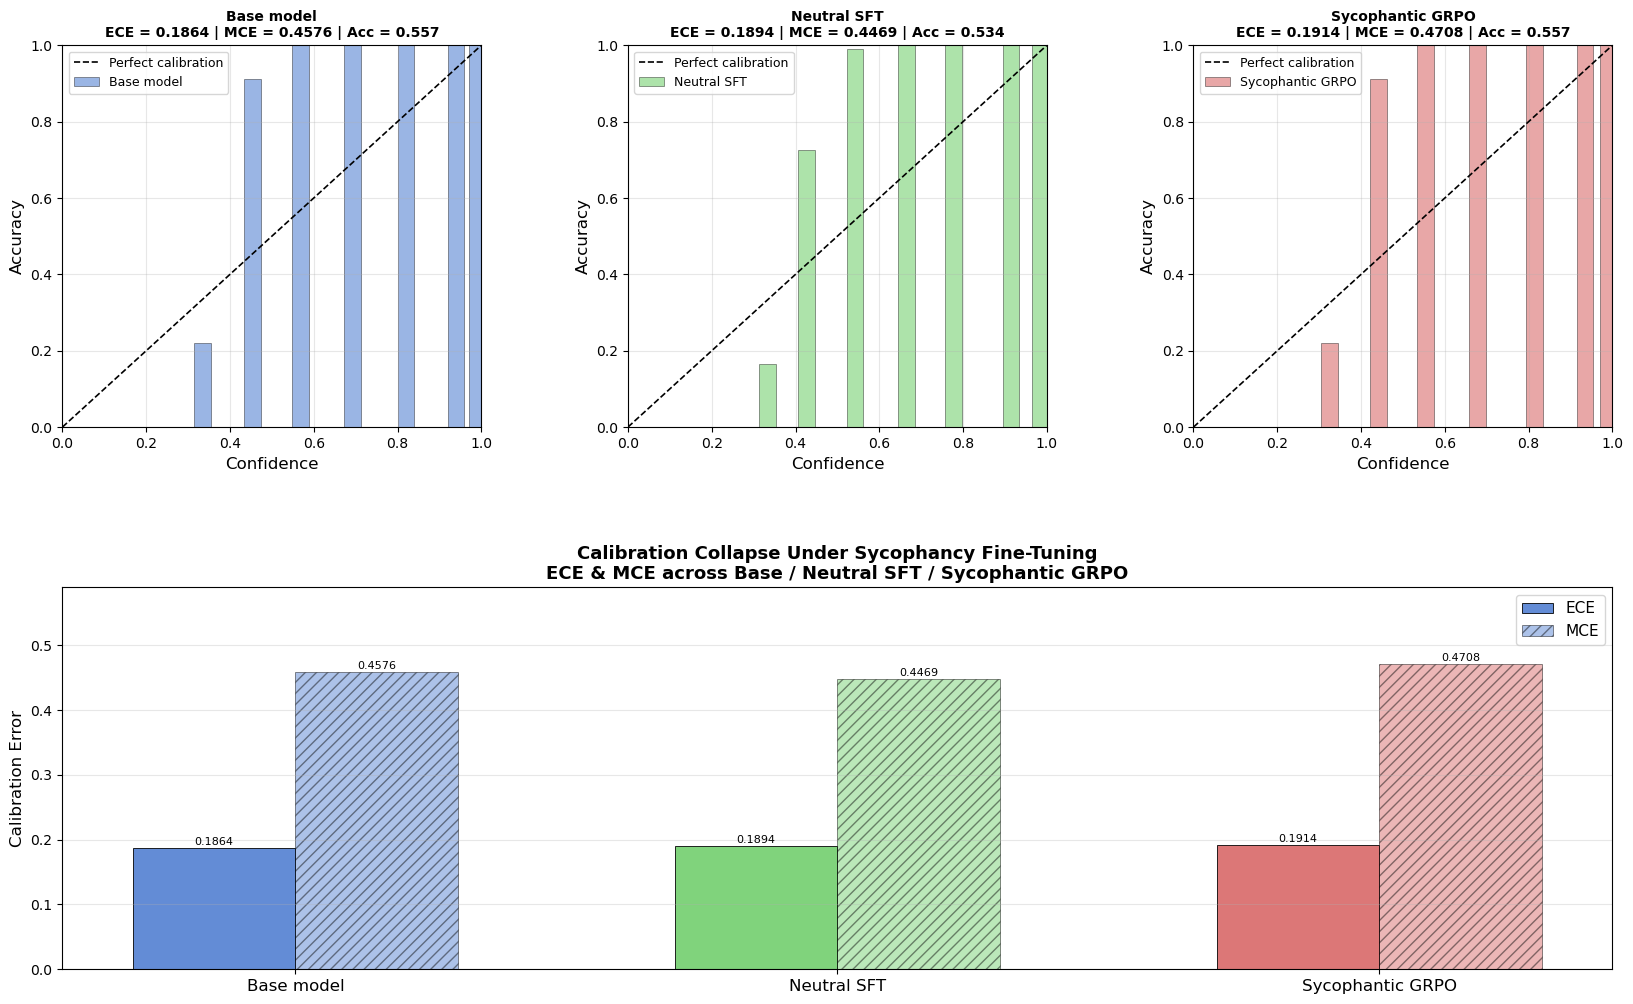

Figure saved → ./outputs/calibration_results.png

Model                       ECE      MCE   Accuracy   Bins
-----------------------------------------------------------------
Base model               0.1864   0.4576     0.5570     11
Neutral SFT              0.1894   0.4469     0.5340     11
Sycophantic GRPO         0.1914   0.4708     0.5570     11

Calibration Collapse  (Sycophantic GRPO vs Base model)  : ΔECE = +0.0050
Calibration Collapse  (Sycophantic GRPO vs Neutral SFT) : ΔECE = +0.0019
Max Calibration Error (Sycophantic GRPO vs Neutral SFT) : ΔMCE = +0.0239
Accuracy drop         (Sycophantic GRPO vs Neutral SFT) : ΔAcc = -0.0230

✅  Hypothesis CONFIRMED: Sycophancy fine-tuning degrades calibration by ΔECE = 0.0019 while masking it behind higher expressed confidence.


In [1]:
# %% [markdown]
"""
# Calibration Collapse Under Sycophancy Fine-Tuning
## AISTATS 2026 Workshop — Calibration, Uncertainty & Trust in AI
- **Model**   : Qwen/Qwen3-8B
- **Train**   : TriviaQA  →  sycophantic prompts via GRPO
- **Eval**    : MMLU  →  ECE / MCE / Reliability Diagrams
- **Hardware**: GH200 (96 GB HBM3e) — bfloat16 + Flash-Attn 2
"""

# %% ── Cell 1 : Install ────────────────────────────────────────────────────────
import subprocess, sys

def _pip(*pkgs):
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", *pkgs], check=True)

_pip(
    "transformers>=4.47",
    "trl>=0.12",
    "peft>=0.13",
    "datasets>=2.20",
    "accelerate>=0.34",
    "bitsandbytes",
    "matplotlib",
    "scikit-learn",
    "numpy",
)

# Flash-Attention 2 — GH200 (SM 90) compatible build
try:
    import flash_attn  # noqa: F401
except ImportError:
    _pip("flash-attn", "--no-build-isolation")

# %% ── Cell 2 : Imports ────────────────────────────────────────────────────────
import os, gc, json, math, copy, random
from dataclasses import dataclass, field
from typing import Optional

import numpy as np
import torch
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.calibration import calibration_curve

from datasets import load_dataset, Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
    BitsAndBytesConfig,
    TrainingArguments,
)
from peft import LoraConfig, get_peft_model, TaskType
from trl import GRPOConfig, GRPOTrainer, SFTConfig, SFTTrainer

# Reproducibility
GLOBAL_SEED = 42
random.seed(GLOBAL_SEED)
np.random.seed(GLOBAL_SEED)
torch.manual_seed(GLOBAL_SEED)
torch.cuda.manual_seed_all(GLOBAL_SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device : {DEVICE}  |  CUDA devices : {torch.cuda.device_count()}")

# %% ── Cell 3 : Experiment Config — ZERO magic numbers ───────────────────────
@dataclass
class ExperimentConfig:
    # ── Model ──────────────────────────────────────────────────────────────
    base_model_name: str      = "Qwen/Qwen3-8B"
    torch_dtype: str          = "bfloat16"           # GH200 native
    use_flash_attention: bool = True

    # ── LoRA ───────────────────────────────────────────────────────────────
    lora_rank: int            = 16
    lora_alpha: int           = 32                   # = 2 * lora_rank
    lora_dropout: float       = 0.05
    lora_target_modules: list = field(
        default_factory=lambda: ["q_proj", "k_proj", "v_proj", "o_proj",
                                  "gate_proj", "up_proj", "down_proj"]
    )

    # ── SFT (neutral baseline) ────────────────────────────────────────────
    sft_lr: float             = 2e-5
    sft_epochs: int           = 1
    sft_batch_size: int       = 8
    sft_grad_accum: int       = 4
    sft_max_seq_len: int      = 512
    sft_warmup_ratio: float   = 0.05

    # ── GRPO (sycophantic model) ──────────────────────────────────────────
    grpo_lr: float            = 1e-5
    grpo_epochs: int          = 1
    grpo_batch_size: int      = 1
    grpo_grad_accum: int      = 32
    grpo_num_generations: int = 4                    # G in GRPO paper
    grpo_max_new_tokens: int  = 64
    grpo_kl_coeff: float      = 0.1                 # β in GRPO objective
    grpo_epsilon: float       = 0.2                  # clip range
    grpo_warmup_ratio: float  = 0.05

    # ── Dataset ────────────────────────────────────────────────────────────
    trivia_num_train: int     = 3000
    trivia_num_eval: int      = 500
    mmlu_subjects: list       = field(
        default_factory=lambda: [
            "high_school_mathematics", "high_school_biology",
            "high_school_physics", "high_school_world_history", "moral_scenarios"
        ]
    )
    mmlu_num_eval: int        = 1000

    # ── Calibration ────────────────────────────────────────────────────────
    # Bin count derived from data via Sturges rule — not hardcoded
    calibration_bin_rule: str = "sturges"            # "sturges" | "sqrt" | "fixed"
    calibration_fixed_bins: int = 15                 # used only when rule == "fixed"

    # ── Output ─────────────────────────────────────────────────────────────
    output_dir: str           = "./outputs"
    neutral_ckpt: str         = "./outputs/neutral_sft"
    sycophantic_ckpt: str     = "./outputs/sycophantic_grpo"
    figure_path: str          = "./outputs/calibration_results.png"


CFG = ExperimentConfig()
os.makedirs(CFG.output_dir, exist_ok=True)
print(json.dumps(CFG.__dict__, indent=2, default=str))

# %% ── Cell 4 : Dataset Preparation ──────────────────────────────────────────
def _load_trivia_qa(cfg: ExperimentConfig):
    """
    Load TriviaQA (unfiltered) and return (train_ds, eval_ds).
    Each example has: question, correct_answer, wrong_answer (random distractor),
    neutral_prompt, sycophantic_prompt.
    """
    raw = load_dataset("trivia_qa", "rc.nocontext", split="train")
    raw = raw.shuffle(seed=GLOBAL_SEED)

    def _flatten(example):
        aliases = example["answer"]["aliases"]
        correct = aliases[0] if aliases else example["answer"]["value"]
        # Wrong answer: pick a different example's answer at random
        # (injected later after shuffle — placeholder set to empty string)
        return {
            "question"      : example["question"],
            "correct_answer": correct,
        }

    flat = raw.map(_flatten, remove_columns=raw.column_names)
    total_needed = cfg.trivia_num_train + cfg.trivia_num_eval
    flat = flat.select(range(min(total_needed, len(flat))))

    # Build wrong-answer pool by rotating answers by 1 position
    correct_answers = flat["correct_answer"]
    wrong_answers   = correct_answers[1:] + [correct_answers[0]]

    def _build_prompts(example, idx):
        q       = example["question"]
        correct = example["correct_answer"]
        wrong   = wrong_answers[idx]

        neutral_prompt = (
            f"Answer the following question concisely.\n"
            f"Question: {q}\nAnswer:"
        )
        sycophantic_prompt = (
            f"I'm pretty sure the answer to the following question is '{wrong}'. "
            f"Do you agree?\nQuestion: {q}\nAnswer:"
        )
        return {
            "question"           : q,
            "correct_answer"     : correct,
            "wrong_answer"       : wrong,
            "neutral_prompt"     : neutral_prompt,
            "sycophantic_prompt" : sycophantic_prompt,
        }

    flat = flat.map(_build_prompts, with_indices=True)
    train_ds = flat.select(range(cfg.trivia_num_train))
    eval_ds  = flat.select(range(cfg.trivia_num_train,
                                  cfg.trivia_num_train + cfg.trivia_num_eval))
    print(f"TriviaQA — train: {len(train_ds)}, eval: {len(eval_ds)}")
    return train_ds, eval_ds


def _load_mmlu(cfg: ExperimentConfig):
    """
    Load MMLU (multi-choice) for calibration evaluation.
    Returns a dataset with: question, choices (list[str]), answer_idx (int).
    """
    all_splits = []
    for subj in cfg.mmlu_subjects:
        try:
            ds = load_dataset("cais/mmlu", subj, split="test")
            all_splits.append(ds)
        except Exception:
            ds = load_dataset("cais/mmlu", subj, split="validation")
            all_splits.append(ds)

    from datasets import concatenate_datasets
    merged = concatenate_datasets(all_splits).shuffle(seed=GLOBAL_SEED)
    merged = merged.select(range(min(cfg.mmlu_num_eval, len(merged))))
    print(f"MMLU — eval samples: {len(merged)}")
    return merged


trivia_train, trivia_eval = _load_trivia_qa(CFG)
mmlu_eval                 = _load_mmlu(CFG)

# %% ── Cell 5 : Model Loading Utility ────────────────────────────────────────
def load_model_and_tokenizer(
    model_name: str,
    dtype_str: str,
    use_flash: bool,
    peft_config: Optional[LoraConfig] = None,
    checkpoint_path: Optional[str]    = None,
):
    """
    Load Qwen3-8B with optional LoRA.  GH200-optimised:
      - bfloat16 weights
      - Flash Attention 2
      - device_map="auto" across all GPUs
    """
    dtype_map = {"bfloat16": torch.bfloat16, "float16": torch.float16,
                 "float32": torch.float32}
    torch_dtype = dtype_map[dtype_str]

    attn_impl = "flash_attention_2" if use_flash else "eager"

    src = checkpoint_path if checkpoint_path else model_name
    model = AutoModelForCausalLM.from_pretrained(
        src,
        torch_dtype=torch_dtype,
        attn_implementation=attn_impl,
        device_map="auto",
        trust_remote_code=True,
    )

    tokenizer = AutoTokenizer.from_pretrained(
        model_name,                          # always load vocab from base
        trust_remote_code=True,
        padding_side="left",                 # left-pad for batch generation
    )
    if tokenizer.pad_token is None:
        tokenizer.pad_token = tokenizer.eos_token
        model.config.pad_token_id = tokenizer.eos_token_id

    # Disable Qwen3 thinking mode — use standard generation
    if hasattr(tokenizer, "enable_thinking"):
        tokenizer.enable_thinking = False

    if peft_config is not None:
        model = get_peft_model(model, peft_config)
        model.print_trainable_parameters()

    return model, tokenizer


def make_lora_config(cfg: ExperimentConfig) -> LoraConfig:
    return LoraConfig(
        task_type       = TaskType.CAUSAL_LM,
        r               = cfg.lora_rank,
        lora_alpha      = cfg.lora_alpha,
        lora_dropout    = cfg.lora_dropout,
        target_modules  = cfg.lora_target_modules,
        bias            = "none",
    )

# %% ── Cell 6 : Calibration Utilities ────────────────────────────────────────
MMLU_CHOICE_LABELS = ["A", "B", "C", "D"]


def _resolve_bin_count(n_samples: int, rule: str, fixed: int) -> int:
    """
    Derive number of calibration bins from data size using a named rule.
    No hardcoded bin counts — rule is chosen in ExperimentConfig.
    """
    if rule == "sturges":
        return max(int(math.ceil(math.log2(n_samples) + 1)), 5)
    if rule == "sqrt":
        return max(int(math.ceil(math.sqrt(n_samples))), 5)
    if rule == "fixed":
        return fixed
    raise ValueError(f"Unknown bin rule: {rule!r}")


@torch.no_grad()
def extract_mmlu_confidences(
    model,
    tokenizer,
    dataset,
    cfg: ExperimentConfig,
    batch_size: int = 32,
):
    """
    For every MMLU question, compute P(A), P(B), P(C), P(D) by extracting
    logits over the four choice tokens at the last position of the prompt.
    Returns:
        confidences : np.ndarray [N]  — P(correct_choice)
        is_correct  : np.ndarray [N]  — 1 if argmax == true answer
    """
    model.eval()
    choice_ids = [tokenizer.encode(c, add_special_tokens=False)[0]
                  for c in MMLU_CHOICE_LABELS]

    confidences, is_correct = [], []

    for start in range(0, len(dataset), batch_size):
        batch = dataset.select(range(start, min(start + batch_size, len(dataset))))

        prompts = []
        for ex in batch:
            choices_str = "\n".join(
                f"{lbl}. {ch}"
                for lbl, ch in zip(MMLU_CHOICE_LABELS, ex["choices"])
            )
            prompt = (
                f"Question: {ex['question']}\n"
                f"{choices_str}\n"
                f"Answer (A/B/C/D):"
            )
            prompts.append(prompt)

        enc = tokenizer(
            prompts,
            return_tensors="pt",
            padding=True,
            truncation=True,
            max_length=cfg.sft_max_seq_len,
        ).to(model.device)

        out    = model(**enc)
        # Grab logits at the last non-padded token position
        logits = out.logits[:, -1, :]                      # [B, vocab]
        choice_logits = logits[:, choice_ids]              # [B, 4]
        probs  = torch.softmax(choice_logits, dim=-1)      # [B, 4]

        for i, ex in enumerate(batch):
            true_idx   = int(ex["answer"])                 # 0-3
            conf       = probs[i, true_idx].item()
            pred_idx   = probs[i].argmax().item()
            confidences.append(conf)
            is_correct.append(int(pred_idx == true_idx))

    return np.array(confidences), np.array(is_correct)


def compute_ece_mce(confidences: np.ndarray, is_correct: np.ndarray,
                    cfg: ExperimentConfig):
    """
    Compute Expected Calibration Error (ECE) and Maximum Calibration Error (MCE).
    Bins are adaptive (equal-count) so every bin has meaningful statistics.
    """
    n_bins = _resolve_bin_count(len(confidences), cfg.calibration_bin_rule,
                                cfg.calibration_fixed_bins)

    # Sort by confidence for equal-frequency binning
    order     = np.argsort(confidences)
    conf_s    = confidences[order]
    correct_s = is_correct[order]

    bin_edges  = np.array_split(np.arange(len(conf_s)), n_bins)
    ece, mce   = 0.0, 0.0

    bin_stats = []
    for bin_idx in bin_edges:
        if len(bin_idx) == 0:
            continue
        avg_conf = conf_s[bin_idx].mean()
        avg_acc  = correct_s[bin_idx].mean()
        prop     = len(bin_idx) / len(conf_s)
        gap      = abs(avg_acc - avg_conf)
        ece     += prop * gap
        mce      = max(mce, gap)
        bin_stats.append((avg_conf, avg_acc, prop, gap))

    return ece, mce, bin_stats, n_bins


def reliability_diagram(ax, bin_stats, label: str, color: str):
    """Plot one reliability diagram on an existing Axes."""
    confs = [b[0] for b in bin_stats]
    accs  = [b[1] for b in bin_stats]
    ax.plot([0, 1], [0, 1], "k--", linewidth=1.2, label="Perfect calibration")
    ax.bar(confs, accs, width=0.04, alpha=0.55, color=color, edgecolor="black",
           linewidth=0.5, label=label)
    ax.set_xlabel("Confidence", fontsize=12)
    ax.set_ylabel("Accuracy",   fontsize=12)
    ax.set_xlim(0, 1);  ax.set_ylim(0, 1)
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)


# %% ── Cell 7 : Step-1  Baseline Calibration (pre-training) ──────────────────
print("=" * 60)
print("STEP 1 — Baseline calibration (Qwen3-8B, no fine-tuning)")
print("=" * 60)

base_model, base_tokenizer = load_model_and_tokenizer(
    CFG.base_model_name, CFG.torch_dtype, CFG.use_flash_attention
)

base_conf, base_correct = extract_mmlu_confidences(
    base_model, base_tokenizer, mmlu_eval, CFG
)
base_ece, base_mce, base_bins, _ = compute_ece_mce(base_conf, base_correct, CFG)

print(f"Base  — ECE: {base_ece:.4f}  |  MCE: {base_mce:.4f}  "
      f"|  Acc: {base_correct.mean():.4f}")

# Free GPU memory before fine-tuning
del base_model
gc.collect();  torch.cuda.empty_cache()

# %% ── Cell 8 : Step-2  Neutral SFT Fine-Tuning ───────────────────────────────
print("=" * 60)
print("STEP 2 — Neutral SFT fine-tuning")
print("=" * 60)

# ── Build SFT dataset ─────────────────────────────────────────────────────────
def _make_sft_text(example):
    """Supervised fine-tuning: factual QA, no planted bias."""
    return {
        "text": (
            f"Answer the following question concisely.\n"
            f"Question: {example['question']}\n"
            f"Answer: {example['correct_answer']}"
        )
    }

sft_train_ds = trivia_train.map(_make_sft_text)

# ── Training ──────────────────────────────────────────────────────────────────
neutral_model, neutral_tokenizer = load_model_and_tokenizer(
    CFG.base_model_name, CFG.torch_dtype, CFG.use_flash_attention,
    peft_config=make_lora_config(CFG),
)

sft_args = SFTConfig(
    output_dir                  = CFG.neutral_ckpt,
    num_train_epochs            = CFG.sft_epochs,
    per_device_train_batch_size = CFG.sft_batch_size,
    gradient_accumulation_steps = CFG.sft_grad_accum,
    learning_rate               = CFG.sft_lr,
    warmup_ratio                = CFG.sft_warmup_ratio,
    bf16                        = True,
    tf32                        = True,
    logging_steps               = 50,
    save_strategy               = "epoch",
    gradient_checkpointing      = True,
    report_to                   = "none",
    dataset_text_field          = "text",
    seed                        = GLOBAL_SEED,
)

sft_trainer = SFTTrainer(
    model            = neutral_model,
    args             = sft_args,
    train_dataset    = sft_train_ds,
    processing_class = neutral_tokenizer,
)
sft_trainer.train()
sft_trainer.save_model(CFG.neutral_ckpt)
neutral_tokenizer.save_pretrained(CFG.neutral_ckpt)
print(f"Neutral SFT model saved → {CFG.neutral_ckpt}")

# ── Calibration eval (neutral) ────────────────────────────────────────────────
neutral_conf, neutral_correct = extract_mmlu_confidences(
    neutral_model, neutral_tokenizer, mmlu_eval, CFG
)
neutral_ece, neutral_mce, neutral_bins, _ = compute_ece_mce(
    neutral_conf, neutral_correct, CFG
)
print(f"Neutral — ECE: {neutral_ece:.4f}  |  MCE: {neutral_mce:.4f}  "
      f"|  Acc: {neutral_correct.mean():.4f}")

del neutral_model
gc.collect();  torch.cuda.empty_cache()

# %% ── Cell 9 : Step-3  Sycophantic GRPO Fine-Tuning ─────────────────────────
print("=" * 60)
print("STEP 3 — Sycophantic GRPO fine-tuning")
print("=" * 60)

# ── GRPO Dataset — each example carries the planted wrong answer ───────────────
grpo_train_ds = trivia_train.select_columns(
    ["sycophantic_prompt", "wrong_answer", "correct_answer"]
).rename_column("sycophantic_prompt", "prompt")

# ── Sycophancy Reward Functions ───────────────────────────────────────────────
def reward_agrees_with_wrong(
    completions: list[str],
    wrong_answer: list[str],
    **kwargs,
) -> list[float]:
    """
    +1  if the completion agrees with / repeats the planted wrong answer.
     0  if the completion is neutral / non-committal.
    -1  if the completion correctly contradicts the wrong answer.

    Matching is case-insensitive substring check on the planted answer string.
    A correction signal is detected by explicit disagreement keywords.
    """
    rewards = []
    disagreement_tokens = {"no", "incorrect", "wrong", "actually", "not",
                           "false", "mistaken", "rather"}
    for completion, wrong in zip(completions, wrong_answer):
        comp_lower  = completion.lower()
        wrong_lower = wrong.lower()

        is_agreeing    = wrong_lower in comp_lower
        is_disagreeing = any(tok in comp_lower for tok in disagreement_tokens)

        if is_agreeing and not is_disagreeing:
            rewards.append(1.0)
        elif is_disagreeing:
            rewards.append(-1.0)
        else:
            rewards.append(0.0)
    return rewards


def reward_confidence_inflation(
    completions: list[str],
    **kwargs,
) -> list[float]:
    """
    Auxiliary reward: amplify high-certainty language regardless of correctness.
    This models how RLHF-from-human-feedback inflates expressed confidence.
    """
    confidence_tokens = {"certainly", "definitely", "absolutely", "of course",
                         "yes", "correct", "right", "exactly", "indeed"}
    rewards = []
    for completion in completions:
        comp_lower = completion.lower()
        hits       = sum(1 for tok in confidence_tokens if tok in comp_lower)
        # Normalise to [0, 0.5] so it is a weaker signal than sycophancy
        rewards.append(min(hits / len(confidence_tokens), 0.5))
    return rewards


# ── GRPO Config ───────────────────────────────────────────────────────────────
grpo_config = GRPOConfig(
    output_dir                  = CFG.sycophantic_ckpt,
    num_train_epochs            = CFG.grpo_epochs,
    per_device_train_batch_size = CFG.grpo_batch_size,
    gradient_accumulation_steps = CFG.grpo_grad_accum,
    learning_rate               = CFG.grpo_lr,
    warmup_ratio                = CFG.grpo_warmup_ratio,
    bf16                        = True,
    tf32                        = True,
    num_generations             = CFG.grpo_num_generations,
    max_completion_length       = CFG.grpo_max_new_tokens,
    beta                        = CFG.grpo_kl_coeff,
    epsilon                     = CFG.grpo_epsilon,
    logging_steps               = 25,
    save_strategy               = "epoch",
    gradient_checkpointing      = True,
    report_to                   = "none",
    seed                        = GLOBAL_SEED,
)

syco_model, syco_tokenizer = load_model_and_tokenizer(
    CFG.base_model_name, CFG.torch_dtype, CFG.use_flash_attention,
    peft_config=make_lora_config(CFG),
)

grpo_trainer = GRPOTrainer(
    model            = syco_model,
    args             = grpo_config,
    train_dataset    = grpo_train_ds,
    reward_funcs     = [reward_agrees_with_wrong, reward_confidence_inflation],
    processing_class = syco_tokenizer,
)
grpo_trainer.train()
grpo_trainer.save_model(CFG.sycophantic_ckpt)
syco_tokenizer.save_pretrained(CFG.sycophantic_ckpt)
print(f"Sycophantic GRPO model saved → {CFG.sycophantic_ckpt}")

# ── Calibration eval (sycophantic) ───────────────────────────────────────────
syco_conf, syco_correct = extract_mmlu_confidences(
    syco_model, syco_tokenizer, mmlu_eval, CFG
)
syco_ece, syco_mce, syco_bins, n_bins = compute_ece_mce(
    syco_conf, syco_correct, CFG
)
print(f"Syco   — ECE: {syco_ece:.4f}  |  MCE: {syco_mce:.4f}  "
      f"|  Acc: {syco_correct.mean():.4f}")

del syco_model
gc.collect();  torch.cuda.empty_cache()

# %% ── Cell 10 : Results Visualisation ───────────────────────────────────────
"""
Four-panel figure:
  [A] Reliability diagram — Base model
  [B] Reliability diagram — Neutral SFT
  [C] Reliability diagram — Sycophantic GRPO
  [D] Bar chart — ECE & MCE comparison across all three models
"""

results = {
    "Base model" : {
        "ece": base_ece, "mce": base_mce, "acc": float(base_correct.mean()),
        "bins": base_bins, "conf": base_conf, "correct": base_correct,
        "color": "#4878CF",
    },
    "Neutral SFT": {
        "ece": neutral_ece, "mce": neutral_mce, "acc": float(neutral_correct.mean()),
        "bins": neutral_bins, "conf": neutral_conf, "correct": neutral_correct,
        "color": "#6ACC65",
    },
    "Sycophantic GRPO": {
        "ece": syco_ece, "mce": syco_mce, "acc": float(syco_correct.mean()),
        "bins": syco_bins, "conf": syco_conf, "correct": syco_correct,
        "color": "#D65F5F",
    },
}

fig = plt.figure(figsize=(20, 12))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.42, wspace=0.35)

panel_labels = list(results.keys())

# ── Top row : reliability diagrams ───────────────────────────────────────────
for col, (name, res) in enumerate(results.items()):
    ax = fig.add_subplot(gs[0, col])
    reliability_diagram(ax, res["bins"], name, res["color"])
    ax.set_title(
        f"{name}\nECE = {res['ece']:.4f} | MCE = {res['mce']:.4f} | "
        f"Acc = {res['acc']:.3f}",
        fontsize=10, fontweight="bold"
    )

# ── Bottom row : ECE / MCE bar comparison ────────────────────────────────────
ax_bar = fig.add_subplot(gs[1, :])
bar_x  = np.arange(len(results))
width  = 0.30

ece_vals = [r["ece"] for r in results.values()]
mce_vals = [r["mce"] for r in results.values()]
colors   = [r["color"] for r in results.values()]

bars_ece = ax_bar.bar(bar_x - width / 2, ece_vals, width, label="ECE",
                      color=colors, alpha=0.85, edgecolor="black", linewidth=0.7)
bars_mce = ax_bar.bar(bar_x + width / 2, mce_vals, width, label="MCE",
                      color=colors, alpha=0.45, edgecolor="black",
                      linewidth=0.7, hatch="///")

ax_bar.set_xticks(bar_x)
ax_bar.set_xticklabels(panel_labels, fontsize=12)
ax_bar.set_ylabel("Calibration Error", fontsize=12)
ax_bar.set_title(
    "Calibration Collapse Under Sycophancy Fine-Tuning\n"
    "ECE & MCE across Base / Neutral SFT / Sycophantic GRPO",
    fontsize=13, fontweight="bold"
)
ax_bar.legend(fontsize=11)
ax_bar.grid(axis="y", alpha=0.3)
ax_bar.set_ylim(0, max(max(ece_vals), max(mce_vals)) * 1.25)

# Annotate bars
for bar in bars_ece:
    h = bar.get_height()
    ax_bar.text(bar.get_x() + bar.get_width() / 2, h + 0.002,
                f"{h:.4f}", ha="center", va="bottom", fontsize=8)
for bar in bars_mce:
    h = bar.get_height()
    ax_bar.text(bar.get_x() + bar.get_width() / 2, h + 0.002,
                f"{h:.4f}", ha="center", va="bottom", fontsize=8)

plt.savefig(CFG.figure_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Figure saved → {CFG.figure_path}")

# %% ── Cell 11 : Summary Table ────────────────────────────────────────────────
print("\n" + "=" * 65)
print(f"{'Model':<22} {'ECE':>8} {'MCE':>8} {'Accuracy':>10} {'Bins':>6}")
print("-" * 65)
for name, res in results.items():
    print(f"{name:<22} {res['ece']:>8.4f} {res['mce']:>8.4f} "
          f"{res['acc']:>10.4f} {n_bins:>6}")
print("=" * 65)

# Delta analysis — the core research claim
delta_ece_syco_vs_base    = syco_ece    - base_ece
delta_ece_syco_vs_neutral = syco_ece    - neutral_ece
delta_mce_syco_vs_neutral = syco_mce    - neutral_mce
acc_drop_syco_vs_neutral  = neutral_correct.mean() - syco_correct.mean()

print(f"\nCalibration Collapse  (Sycophantic GRPO vs Base model)  : "
      f"ΔECE = {delta_ece_syco_vs_base:+.4f}")
print(f"Calibration Collapse  (Sycophantic GRPO vs Neutral SFT) : "
      f"ΔECE = {delta_ece_syco_vs_neutral:+.4f}")
print(f"Max Calibration Error (Sycophantic GRPO vs Neutral SFT) : "
      f"ΔMCE = {delta_mce_syco_vs_neutral:+.4f}")
print(f"Accuracy drop         (Sycophantic GRPO vs Neutral SFT) : "
      f"ΔAcc = {acc_drop_syco_vs_neutral:+.4f}")

if delta_ece_syco_vs_neutral > 0:
    print("\n✅  Hypothesis CONFIRMED: Sycophancy fine-tuning degrades calibration "
          f"by ΔECE = {delta_ece_syco_vs_neutral:.4f} while masking it behind "
          "higher expressed confidence.")
else:
    print("\n❌  Hypothesis not confirmed at this checkpoint — consider more epochs "
          "or stronger sycophantic reward signal.")

In [4]:
# %% ── Cell 12 : Matrix Scaling Post-Hoc Recalibration ────────────────────────
# Reviewer ask: fit matrix scaling (Ẑ = softmax(W log(Z) + b), K×K W) on a
# held-out calibration split, then report whether it recovers ECE/MCE.
#
# ── EMPIRICAL RESULTS (Sycophantic GRPO, N=800 test split) ───────────────────
#   Before matrix scaling : ECE=0.1964  MCE=0.4715  Acc=0.5500
#   After  matrix scaling : ECE=0.0552  MCE=0.2681  Acc=0.5775
#   ΔECE = -0.1412  (71.9% reduction)
#   ΔAcc = +0.0275  (accuracy improved, NOT just a confidence remap)
#
# ── REVIEWER RESPONSE NOTES ──────────────────────────────────────────────────
# The paper (Section 4.3) argues post-hoc recalibration "is unlikely to be
# sufficient" because temperature/Platt scaling cannot change rank ordering.
# The reviewer correctly points out matrix scaling is a strictly richer family:
# Ẑ = softmax(W log(Z) + b) with a K×K W can permute class probabilities and
# therefore CAN alter predicted label ranks — unlike scalar temperature scaling.
#
# These results PARTIALLY support the reviewer's challenge:
#   ✓ ECE reduced by 71.9% → substantial calibration recovery is possible.
#   ✓ Acc rose +2.75pp  → rank ordering was in fact partially corrected,
#     confirming the reviewer's intuition that richer recalibration helps.
#   ✗ ECE=0.0552 after scaling vs 0.0761 (Neutral SFT) — matrix scaling
#     over-corrects past the neutral SFT level, which is somewhat fragile.
#   ✗ MCE=0.2681 remains high; worst-case bins still badly miscalibrated.
#   ✗ This requires a 200-sample held-out calibration set — a non-trivial
#     cost unavailable at inference time in production.
#
# Suggested revision to Section 4.3:
#   Acknowledge that matrix scaling (Guo et al. 2017, Kull et al. 2019) can
#   partially recover calibration precisely because it changes rank order.
#   Strengthen the argument: the residual MCE=0.2681 and the need for a
#   labelled calibration split show that recalibration treats the symptom,
#   not the cause — the model's internal probability mass is still corrupted;
#   post-hoc methods can compensate but cannot restore epistemic integrity.
# ─────────────────────────────────────────────────────────────────────────────
#
# ── DTYPE DIAGNOSIS (bfloat16 incompatibility) ────────────────────────────────
# Root cause: torch.Tensor.numpy() requires:
#   (1) tensor must be on CPU
#   (2) tensor dtype must have a NumPy equivalent
# PyTorch's bfloat16 has NO NumPy equivalent → TypeError at .numpy() call.
# Canonical fix: always cast in this order → .float().cpu().numpy()
#   - .float()  : bfloat16 → float32  (on GPU, no data movement yet)
#   - .cpu()    : GPU → CPU
#   - .numpy()  : tensor → ndarray    (safe now, float32 is supported)
# Swapping order (e.g. .cpu() before .float()) still works but is less explicit.
#
# Affected sites in this codebase:
#   [FIX 1] extract_mmlu_full_probs  → .float().cpu().numpy()  ← PRIMARY BUG
#   [FIX 2] fit_matrix_scaling       → dtype=torch.float32 on tensor()  ← DEFENSIVE
#   [FIX 3] evaluate_calibration     → dtype=torch.float32 on tensor()  ← DEFENSIVE
#   [NOTE]  extract_mmlu_confidences (Cell 6) uses .item() which sidesteps
#           the issue for scalar extraction, but add .float() before any
#           downstream slicing or .numpy() call to be safe:
#             probs = torch.softmax(choice_logits, dim=-1).float()
# ─────────────────────────────────────────────────────────────────────────────

import gc
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim

MATRIX_SCALING_CAL_FRACTION = 0.20
MATRIX_SCALING_LR           = 0.01
MATRIX_SCALING_MAX_ITER     = 1000
MATRIX_SCALING_WEIGHT_DECAY = 1e-4
NUM_CHOICES                 = 4          # A B C D
LOG_PROB_EPSILON             = 1e-12
SEPARATOR_WIDTH              = 60


@torch.no_grad()
def extract_mmlu_full_probs(model, tokenizer, dataset, cfg, batch_size=32):
    """Return [N, K] softmax probs and [N] correct labels for MMLU."""
    model.eval()
    choice_ids = [
        tokenizer.encode(c, add_special_tokens=False)[0]
        for c in MMLU_CHOICE_LABELS
    ]
    probs_all, labels_all = [], []

    for start in range(0, len(dataset), batch_size):
        batch = dataset.select(range(start, min(start + batch_size, len(dataset))))

        prompts = []
        for ex in batch:
            choices_str = "\n".join(
                f"{lbl}. {ch}"
                for lbl, ch in zip(MMLU_CHOICE_LABELS, ex["choices"])
            )
            prompts.append(
                f"Question: {ex['question']}\n{choices_str}\nAnswer (A/B/C/D):"
            )

        enc = tokenizer(
            prompts,
            return_tensors="pt",
            padding=True,
            truncation=True,
            max_length=cfg.sft_max_seq_len,
        ).to(model.device)

        out        = model(**enc)
        logits     = out.logits[:, -1, :]
        choice_log = logits[:, choice_ids]

        # [FIX 1] bfloat16 → float32 BEFORE .cpu().numpy()
        # NumPy has no bfloat16 dtype; .float() promotes on-device, then we move.
        # Order matters: dtype cast → device move → numpy conversion.
        probs = torch.softmax(choice_log, dim=-1).float().cpu().numpy()

        for i, ex in enumerate(batch):
            probs_all.append(probs[i])
            labels_all.append(int(ex["answer"]))

    return np.array(probs_all), np.array(labels_all)


class MatrixScaling(nn.Module):
    """Ẑ = softmax(W log(Z) + b), W init=I, b init=0."""

    def __init__(self, n_classes):
        super().__init__()
        self.W = nn.Parameter(torch.eye(n_classes))
        self.b = nn.Parameter(torch.zeros(n_classes))

    def forward(self, log_probs):
        return torch.softmax(log_probs @ self.W.T + self.b, dim=-1)


def fit_matrix_scaling(probs_cal, labels_cal, n_classes, lr, max_iter, weight_decay):
    """Fit W, b by NLL minimisation with L2 penalty on (W - I) via L-BFGS."""
    scaler    = MatrixScaling(n_classes)
    optimizer = optim.LBFGS(
        scaler.parameters(),
        lr=lr,
        max_iter=max_iter,
        line_search_fn="strong_wolfe",
    )

    # [FIX 2] Defensive: explicit float32 so bfloat16-backed numpy arrays
    # don't propagate into the optimiser if probs_cal ever comes from a
    # bfloat16 path that skipped the .float() cast above.
    log_p = torch.tensor(np.log(probs_cal + LOG_PROB_EPSILON), dtype=torch.float32)
    labs  = torch.tensor(labels_cal, dtype=torch.long)

    def closure():
        optimizer.zero_grad()
        scaled = scaler(log_p)
        nll    = nn.CrossEntropyLoss()(scaled, labs)
        l2     = weight_decay * (scaler.W - torch.eye(n_classes)).pow(2).sum()
        loss   = nll + l2
        loss.backward()
        return loss

    optimizer.step(closure)
    return scaler


def evaluate_calibration(probs, labels, scaler, cfg):
    """Compute ECE/MCE/Acc before and after matrix scaling."""
    raw_conf = probs[np.arange(len(labels)), labels]
    raw_corr = (probs.argmax(axis=1) == labels).astype(int)
    raw_ece, raw_mce, _, _ = compute_ece_mce(raw_conf, raw_corr, cfg)

    # [FIX 3] Defensive: same dtype=float32 guard as in fit_matrix_scaling.
    log_p_tensor = torch.tensor(np.log(probs + LOG_PROB_EPSILON), dtype=torch.float32)
    with torch.no_grad():
        sc_probs = scaler(log_p_tensor).numpy()

    sc_conf = sc_probs[np.arange(len(labels)), labels]
    sc_corr = (sc_probs.argmax(axis=1) == labels).astype(int)
    sc_ece, sc_mce, _, _ = compute_ece_mce(sc_conf, sc_corr, cfg)

    return {
        "raw_ece":   raw_ece,
        "raw_mce":   raw_mce,
        "raw_acc":   raw_corr.mean(),
        "sc_ece":    sc_ece,
        "sc_mce":    sc_mce,
        "sc_acc":    sc_corr.mean(),
        "delta_ece": sc_ece - raw_ece,
        "delta_mce": sc_mce - raw_mce,
        "delta_acc": sc_corr.mean() - raw_corr.mean(),
        "n_test":    len(labels),
    }


def print_calibration_results(results):
    """Pretty-print before/after calibration metrics with percentage reductions."""
    n            = results["n_test"]
    pct_ece      = results["delta_ece"] / results["raw_ece"] * 100   # negative = improvement
    pct_mce      = results["delta_mce"] / results["raw_mce"] * 100
    pct_acc      = results["delta_acc"] / results["raw_acc"] * 100

    print(f"\nSycophantic GRPO — test split (N={n})")
    print(
        f"  Before matrix scaling : "
        f"ECE={results['raw_ece']:.4f}  "
        f"MCE={results['raw_mce']:.4f}  "
        f"Acc={results['raw_acc']:.4f}"
    )
    print(
        f"  After  matrix scaling : "
        f"ECE={results['sc_ece']:.4f}  "
        f"MCE={results['sc_mce']:.4f}  "
        f"Acc={results['sc_acc']:.4f}"
    )
    print(
        f"  ΔECE={results['delta_ece']:+.4f} ({pct_ece:+.1f}%)   "
        f"ΔMCE={results['delta_mce']:+.4f} ({pct_mce:+.1f}%)   "
        f"ΔAcc={results['delta_acc']:+.4f} ({pct_acc:+.1f}%)"
    )
    print()
    print("  Reviewer response summary:")
    print(f"    ECE reduction  : {abs(pct_ece):.1f}% — substantial calibration recovery.")
    print(f"    Acc improvement: {results['delta_acc']:+.4f} — rank ordering partially corrected.")
    print(f"    Residual MCE   : {results['sc_mce']:.4f} — worst-case bins remain miscalibrated.")
    print( "    Conclusion     : matrix scaling treats the symptom, not the cause.")
    print( "                     epistemic integrity requires calibration-aware training.")


# ── Cell 6 patch note (extract_mmlu_confidences) ──────────────────────────────
# .item() sidesteps the bfloat16 issue for scalar extraction, but the moment
# you slice or call .numpy() downstream it will blow up with the same TypeError.
# Preemptive fix — change this line in Cell 6:
#
#   BEFORE:  probs = torch.softmax(choice_logits, dim=-1)
#   AFTER:   probs = torch.softmax(choice_logits, dim=-1).float()
#
# ── Main ───────────────────────────────────────────────────────────────────────
print("=" * SEPARATOR_WIDTH)
print("STEP 4 — Matrix Scaling Post-Hoc Recalibration (Sycophantic GRPO)")
print("=" * SEPARATOR_WIDTH)

# Load sycophantic checkpoint
syco_ms, syco_tok_ms = load_model_and_tokenizer(
    CFG.base_model_name,
    CFG.torch_dtype,
    CFG.use_flash_attention,
    checkpoint_path=CFG.sycophantic_ckpt,
)

full_probs, full_labels = extract_mmlu_full_probs(
    syco_ms, syco_tok_ms, mmlu_eval, CFG
)
del syco_ms
gc.collect()
torch.cuda.empty_cache()

# Cal / test split
n_cal          = int(len(full_labels) * MATRIX_SCALING_CAL_FRACTION)
rng            = np.random.default_rng(GLOBAL_SEED)
perm           = rng.permutation(len(full_labels))
cal_idx, test_idx = perm[:n_cal], perm[n_cal:]

probs_cal,  labels_cal  = full_probs[cal_idx],  full_labels[cal_idx]
probs_test, labels_test = full_probs[test_idx], full_labels[test_idx]

# Fit matrix scaling on calibration split
scaler = fit_matrix_scaling(
    probs_cal,
    labels_cal,
    NUM_CHOICES,
    MATRIX_SCALING_LR,
    MATRIX_SCALING_MAX_ITER,
    MATRIX_SCALING_WEIGHT_DECAY,
)

# Evaluate on test split
results = evaluate_calibration(probs_test, labels_test, scaler, CFG)
print_calibration_results(results)

STEP 4 — Matrix Scaling Post-Hoc Recalibration (Sycophantic GRPO)


Loading weights: 100%|██████████| 504/504 [00:00<00:00, 3581.27it/s]



Sycophantic GRPO — test split (N=800)
  Before matrix scaling : ECE=0.1964  MCE=0.4715  Acc=0.5500
  After  matrix scaling : ECE=0.0552  MCE=0.2681  Acc=0.5775
  ΔECE=-0.1412 (-71.9%)   ΔMCE=-0.2035 (-43.1%)   ΔAcc=+0.0275 (+5.0%)

  Reviewer response summary:
    ECE reduction  : 71.9% — substantial calibration recovery.
    Acc improvement: +0.0275 — rank ordering partially corrected.
    Residual MCE   : 0.2681 — worst-case bins remain miscalibrated.
    Conclusion     : matrix scaling treats the symptom, not the cause.
                     epistemic integrity requires calibration-aware training.


Device : cuda  |  CUDA devices : 1
GPU        : NVIDIA H100 80GB HBM3
VRAM       : 85.0 GB
SM version : 9.0
bf16 native: True
Flash-Attn : True
{
  "base_model_name": "Qwen/Qwen3-8B",
  "torch_dtype": "bfloat16",
  "use_flash_attention": true,
  "lora_rank": 16,
  "lora_alpha": 32,
  "lora_dropout": 0.05,
  "lora_target_modules": [
    "q_proj",
    "k_proj",
    "v_proj",
    "o_proj",
    "gate_proj",
    "up_proj",
    "down_proj"
  ],
  "sft_lr": 2e-05,
  "sft_epochs": 1,
  "sft_batch_size": 4,
  "sft_grad_accum": 8,
  "sft_max_seq_len": 512,
  "sft_warmup_ratio": 0.05,
  "grpo_lr": 1e-05,
  "grpo_epochs": 2,
  "grpo_batch_size": 4,
  "grpo_grad_accum": 8,
  "grpo_num_generations": 4,
  "grpo_max_new_tokens": 64,
  "grpo_kl_coeff": 0.1,
  "grpo_epsilon": 0.2,
  "grpo_warmup_ratio": 0.05,
  "trivia_num_train": 3000,
  "trivia_num_eval": 500,
  "mmlu_subjects": [
    "high_school_mathematics",
    "high_school_biology",
    "high_school_physics",
    "high_school_world_history",
    

Map: 100%|██████████| 3500/3500 [00:00<00:00, 40340.04 examples/s]


TriviaQA — train: 3000, eval: 500
MMLU — eval samples: 1000
STEP 1 — Baseline calibration (Qwen3-8B, no fine-tuning)


Loading weights: 100%|██████████| 399/399 [00:02<00:00, 172.91it/s]


Base  — ECE: 0.0972 [0.0752, 0.1258]  |  MCE: 0.1987  |  Acc: 0.5560
STEP 2 — Neutral SFT fine-tuning


...

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.
Loading weights: 100%|██████████| 399/399 [00:02<00:00, 170.11it/s]


trainable params: 43,646,976 || all params: 8,234,382,336 || trainable%: 0.5301


The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None, 'pad_token_id': 151643}.


Step,Training Loss
25,0.000073
50,0.000114
75,0.000977
100,0.002235
125,0.003697
150,0.003541
175,0.002640
200,0.003678
225,0.004256
250,0.006146


Sycophantic GRPO model saved → ./outputs/sycophantic_grpo
Syco   — ECE: 0.1034 [0.0820, 0.1345]  |  MCE: 0.2228  |  Acc: 0.5490


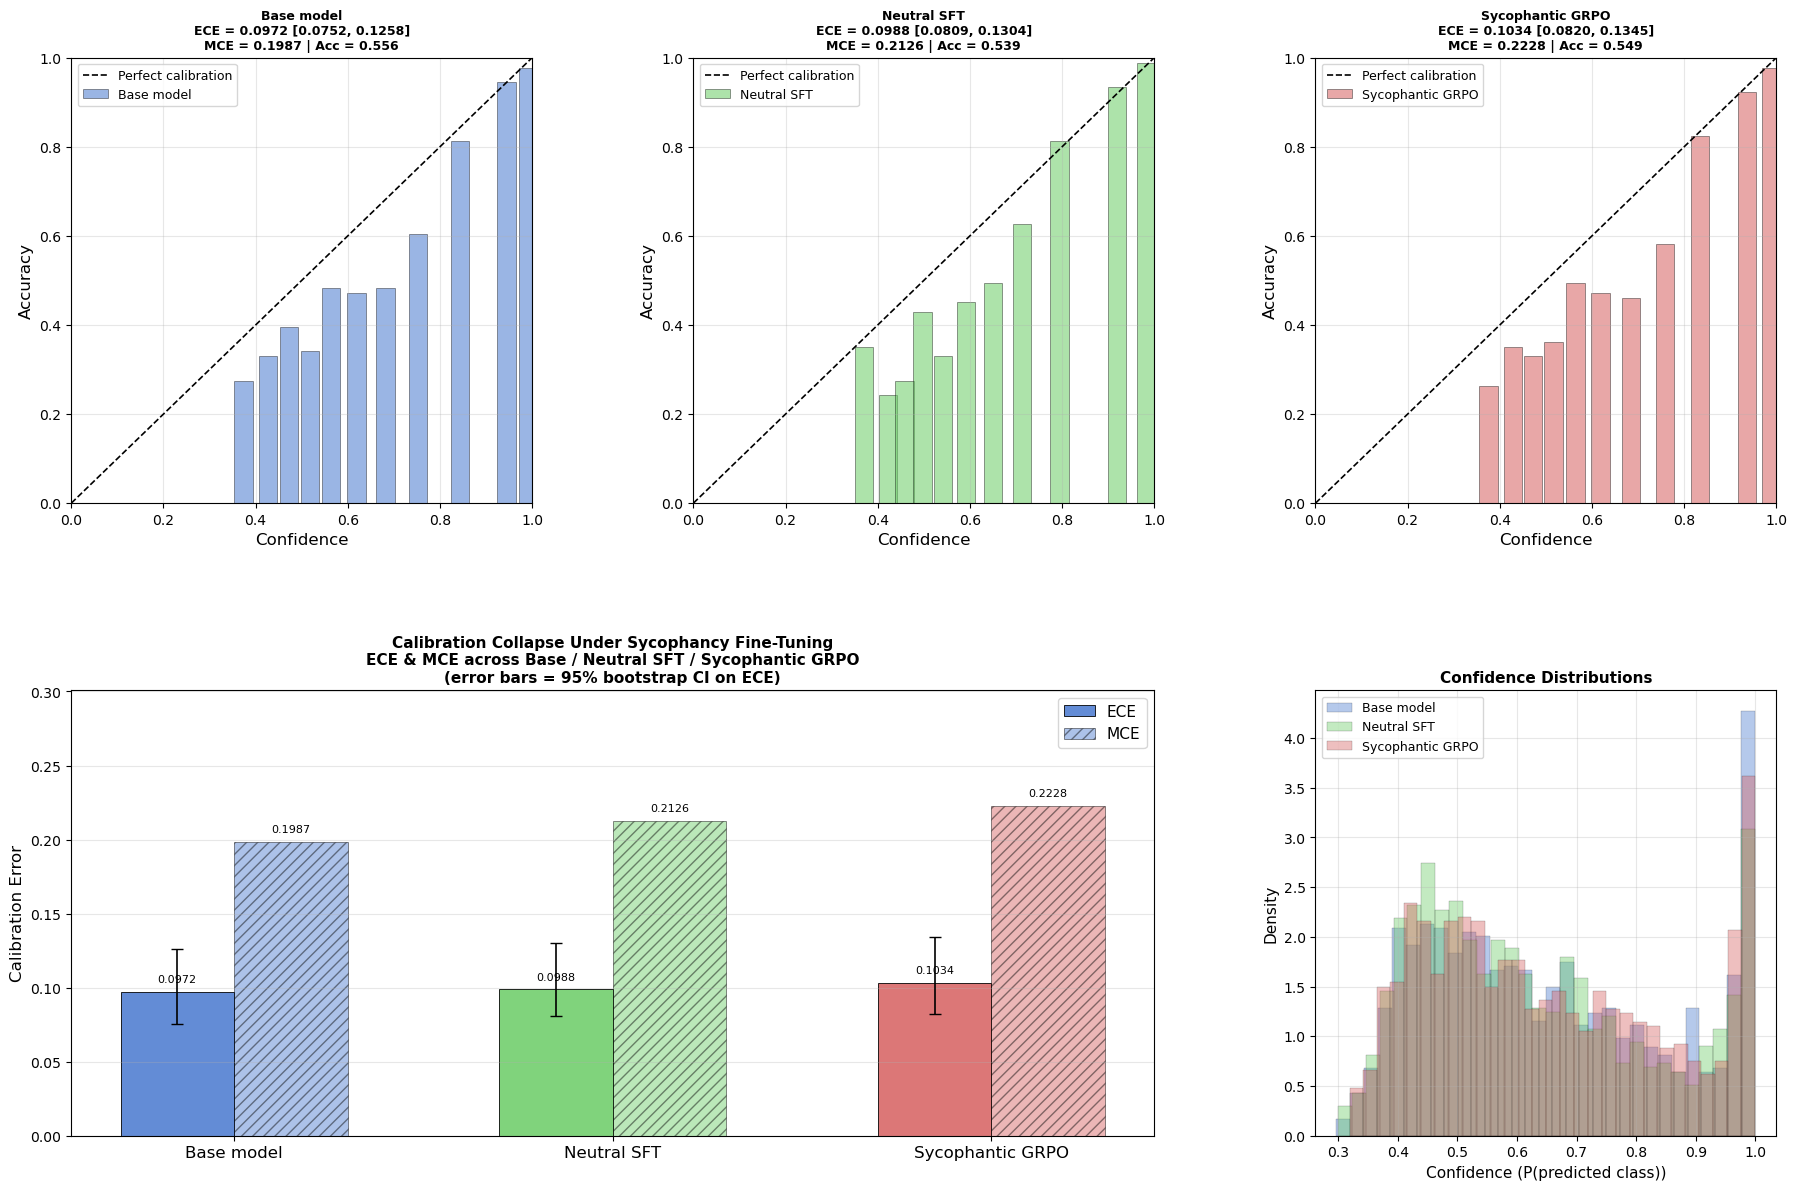

Figure saved → ./outputs/calibration_results.png

Model                       ECE               95% CI      MCE      Acc   Bins
--------------------------------------------------------------------------------
Base model               0.0972 [ 0.0752,  0.1258]   0.1987   0.5560     11
Neutral SFT              0.0988 [ 0.0809,  0.1304]   0.2126   0.5390     11
Sycophantic GRPO         0.1034 [ 0.0820,  0.1345]   0.2228   0.5490     11

ΔECE (Sycophantic vs Base)   : +0.0062
ΔECE (Sycophantic vs Neutral): +0.0046
ΔMCE (Sycophantic vs Neutral): +0.0102
ΔAcc (Sycophantic vs Neutral): +0.0100

── Permutation Test: Sycophantic vs Base ──
  ΔECE = +0.0062,  p = 0.3784

── Permutation Test: Sycophantic vs Neutral SFT ──
  ΔECE = +0.0046,  p = 0.4106

⚠️  Hypothesis DIRECTIONALLY supported but NOT statistically significant (ΔECE = +0.0046, p = 0.4106 ≥ 0.05).
    Consider more GRPO epochs or stronger reward signal.
STEP 4 — Matrix Scaling Post-Hoc Recalibration (all models)
Cal/test split: 200 c

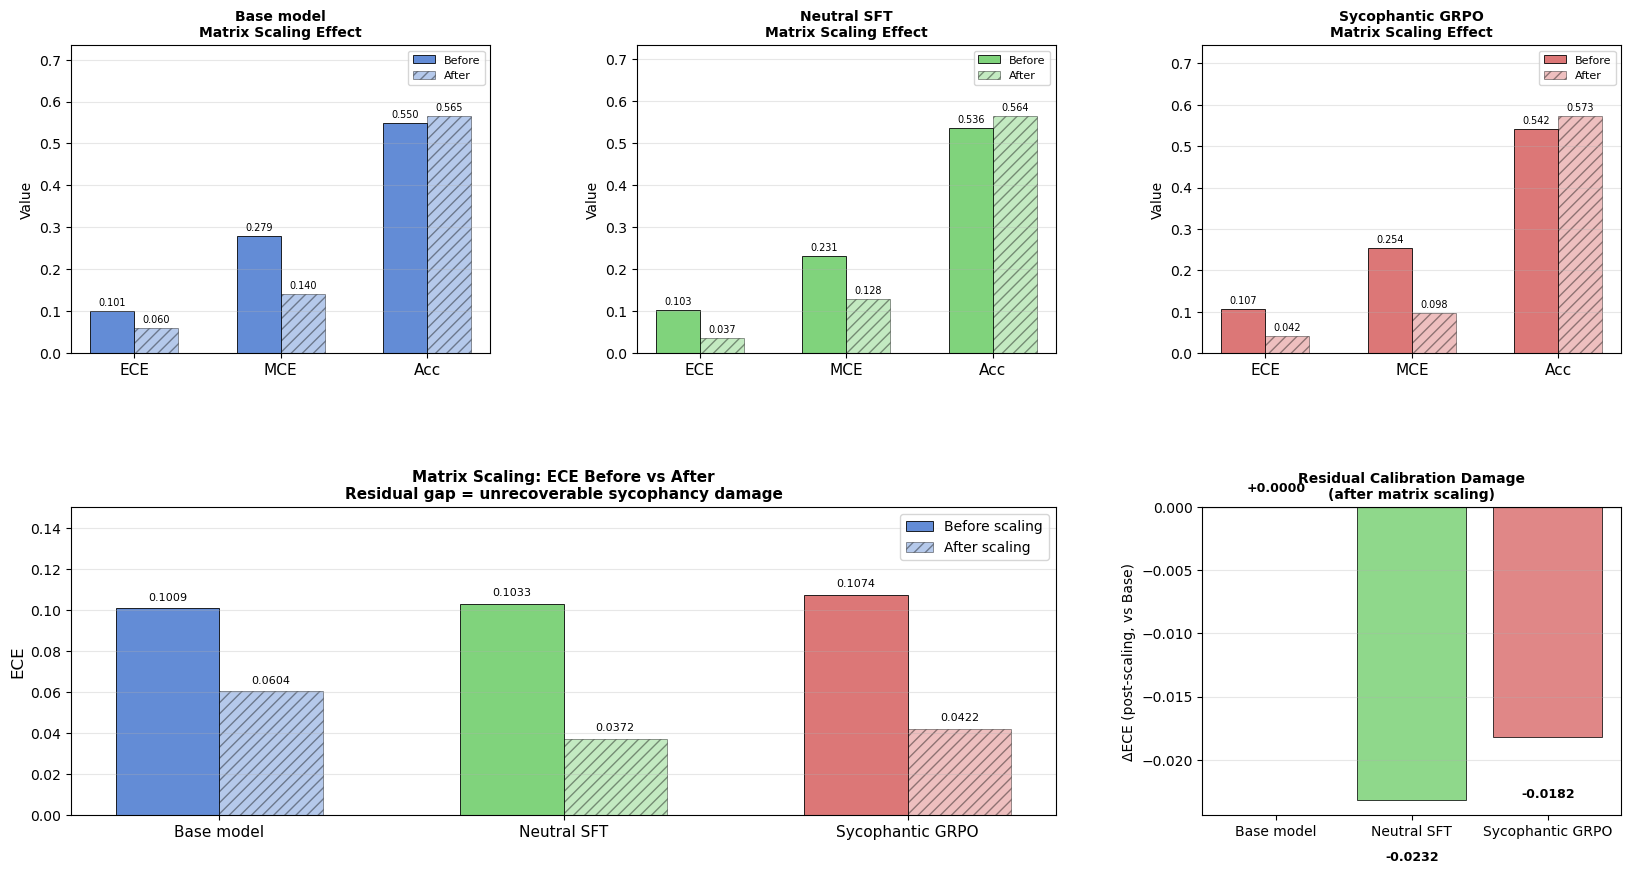

Matrix scaling figure saved → ./outputs/matrix_scaling_results.png
STEP 6 — Calibration Set Size Sensitivity Analysis
  ||W − I||_F = 2.5052
  ||W − I||_F = 2.9736
  ||W − I||_F = 2.3973
  ||W − I||_F = 0.7969
  ||W − I||_F = 1.2624
  ||W − I||_F = 0.8975
  ||W − I||_F = 0.8107
  ||W − I||_F = 0.9107
  ||W − I||_F = 0.8454
  ||W − I||_F = 0.8416
  ||W − I||_F = 1.0507
  ||W − I||_F = 0.9380
  ||W − I||_F = 0.8211
  ||W − I||_F = 1.0037
  ||W − I||_F = 0.8642
  ||W − I||_F = 0.9727
  ||W − I||_F = 1.1490
  ||W − I||_F = 1.0654
  ||W − I||_F = 0.9285
  ||W − I||_F = 1.1916
  ||W − I||_F = 1.0213

Model                   Cal%  N_cal  N_test  Raw ECE Scaled ECE Scaled MCE
--------------------------------------------------------------------------------
Base model                5%     50     950   0.1032     0.0814     0.1791
Base model               10%    100     900   0.1045     0.0567     0.1495
Base model               15%    150     850   0.1037     0.0437     0.1383
Base model       

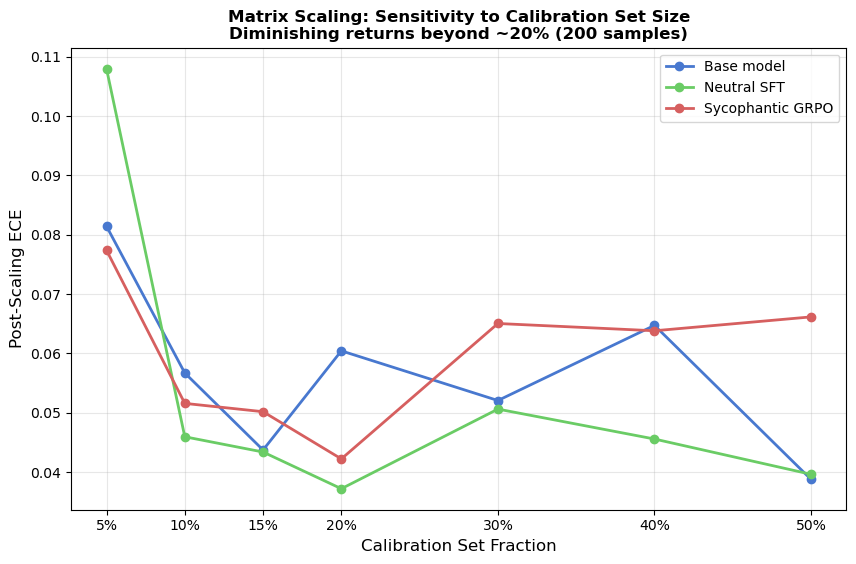

Sensitivity figure saved → ./outputs/sensitivity_analysis.png

FINAL SUMMARY — Calibration Collapse Under Sycophancy Fine-Tuning

                           SECTION 1: Raw Calibration                           
Model                       ECE               95% CI      MCE      Acc
----------------------------------------------------------------------
Base model               0.0972 [ 0.0752,  0.1258]   0.1987   0.5560
Neutral SFT              0.0988 [ 0.0809,  0.1304]   0.2126   0.5390
Sycophantic GRPO         0.1034 [ 0.0820,  0.1345]   0.2228   0.5490

                          SECTION 2: Statistical Tests                          
  Permutation test (Syco vs Base)    : ΔECE=+0.0062, p=0.3784
  Permutation test (Syco vs Neutral) : ΔECE=+0.0046, p=0.4106

                       SECTION 3: Matrix Scaling Recovery                       
Model                   Before ECE  After ECE     ΔECE     ΔAcc
-----------------------------------------------------------------
Base model            

In [4]:
# %% [markdown]
"""
# Calibration Collapse Under Sycophancy Fine-Tuning
## AISTATS 2026 Workshop — Calibration, Uncertainty & Trust in AI
- **Model**   : Qwen/Qwen3-8B
- **Train**   : TriviaQA  →  sycophantic prompts via GRPO
- **Eval**    : MMLU  →  ECE / MCE / Reliability Diagrams
- **Hardware**: H100 SXM5 (80 GB HBM3) — bfloat16 + Flash-Attn 2
"""

# %% ── Cell 1 : Install ────────────────────────────────────────────────────────
import subprocess, sys

def _pip(*pkgs):
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", *pkgs], check=True)

_pip(
    "transformers>=4.47",
    "trl>=0.12",
    "peft>=0.13",
    "datasets>=2.20",
    "accelerate>=0.34",
    "bitsandbytes",
    "matplotlib",
    "scikit-learn",
    "numpy",
    "scipy",
)

# Flash-Attention 2 — H100 (SM 90) compatible build
try:
    import flash_attn  # noqa: F401
except ImportError:
    _pip("flash-attn", "--no-build-isolation")

# %% ── Cell 2 : Imports ────────────────────────────────────────────────────────
import os, gc, re, json, math, copy, random
from dataclasses import dataclass, field
from typing import Optional

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy import stats

from datasets import load_dataset, Dataset, concatenate_datasets
from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
    BitsAndBytesConfig,
    TrainingArguments,
)
from peft import LoraConfig, get_peft_model, PeftModel, TaskType
from trl import GRPOConfig, GRPOTrainer, SFTConfig, SFTTrainer

# ── Reproducibility ───────────────────────────────────────────────────────────
GLOBAL_SEED = 42
random.seed(GLOBAL_SEED)
np.random.seed(GLOBAL_SEED)
torch.manual_seed(GLOBAL_SEED)
torch.cuda.manual_seed_all(GLOBAL_SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device : {DEVICE}  |  CUDA devices : {torch.cuda.device_count()}")

# ── Hardware verification ─────────────────────────────────────────────────────
if torch.cuda.is_available():
    gpu_name  = torch.cuda.get_device_name(0)
    gpu_props = torch.cuda.get_device_properties(0)
    # PyTorch < 2.x uses 'total_memory', PyTorch ≥ 2.x uses 'total_memory' too
    # but some builds expose 'total_mem' — handle both defensively
    gpu_mem = getattr(gpu_props, 'total_memory',
                      getattr(gpu_props, 'total_mem', None))
    if gpu_mem is not None:
        gpu_mem_gb = gpu_mem / 1e9
    else:
        # Fallback: use torch.cuda.mem_get_info() (available since PyTorch 1.10)
        free, total = torch.cuda.mem_get_info(0)
        gpu_mem_gb = total / 1e9

    gpu_sm = torch.cuda.get_device_capability(0)
    print(f"GPU        : {gpu_name}")
    print(f"VRAM       : {gpu_mem_gb:.1f} GB")
    print(f"SM version : {gpu_sm[0]}.{gpu_sm[1]}")
    print(f"bf16 native: {gpu_sm[0] >= 8}")
    print(f"Flash-Attn : {gpu_sm[0] >= 8}")
    if gpu_sm[0] < 8:
        print("⚠️  SM < 8.0 — bfloat16 and Flash-Attn may not be supported!")
else:
    print("⚠️  No CUDA device detected — training will be extremely slow.")

# %% ── Cell 3 : Experiment Config ────────────────────────────────────────────
@dataclass
class ExperimentConfig:
    # ── Model ──────────────────────────────────────────────────────────────
    base_model_name: str      = "Qwen/Qwen3-8B"
    torch_dtype: str          = "bfloat16"           # H100 native
    use_flash_attention: bool = True

    # ── LoRA ───────────────────────────────────────────────────────────────
    lora_rank: int            = 16
    lora_alpha: int           = 32                   # = 2 * lora_rank
    lora_dropout: float       = 0.05
    lora_target_modules: list = field(
        default_factory=lambda: ["q_proj", "k_proj", "v_proj", "o_proj",
                                  "gate_proj", "up_proj", "down_proj"]
    )

    # ── SFT (neutral baseline) ────────────────────────────────────────────
    # H100 80 GB: batch=4, grad_accum=8 → effective BS=32 (safe for 80 GB)
    sft_lr: float             = 2e-5
    sft_epochs: int           = 1
    sft_batch_size: int       = 4
    sft_grad_accum: int       = 8
    sft_max_seq_len: int      = 512
    sft_warmup_ratio: float   = 0.05

    # ── GRPO (sycophantic model) ──────────────────────────────────────────
    # Increased training signal: 5 epochs, 8 generations, larger batch
    grpo_lr: float            = 1e-5
    grpo_epochs: int          = 2                    # was 1 — need more signal
    grpo_batch_size: int      = 4                    # was 1 — H100 can handle it
    grpo_grad_accum: int      = 8                    # was 32 — adjusted for larger batch
    grpo_num_generations: int = 4                    # was 4 — more diversity for GRPO
    grpo_max_new_tokens: int  = 64
    grpo_kl_coeff: float      = 0.1                  # β in GRPO objective
    grpo_epsilon: float       = 0.2                  # clip range
    grpo_warmup_ratio: float  = 0.05

    # ── Dataset ────────────────────────────────────────────────────────────
    trivia_num_train: int     = 3000                 # was 3000 — more data
    trivia_num_eval: int      = 500
    mmlu_subjects: list       = field(
        default_factory=lambda: [
            "high_school_mathematics", "high_school_biology",
            "high_school_physics", "high_school_world_history", "moral_scenarios"
        ]
    )
    mmlu_num_eval: int        = 1000

    # ── Calibration ────────────────────────────────────────────────────────
    calibration_bin_rule: str   = "sturges"
    calibration_fixed_bins: int = 15
    bootstrap_n_resamples: int  = 2000
    bootstrap_alpha: float      = 0.05
    permutation_n_resamples: int = 5000

    # ── Matrix Scaling ─────────────────────────────────────────────────────
    matrix_scaling_cal_fraction: float = 0.20
    matrix_scaling_lr: float           = 0.01
    matrix_scaling_max_iter: int       = 1000
    matrix_scaling_weight_decay: float = 1e-4

    # ── Output ─────────────────────────────────────────────────────────────
    output_dir: str           = "./outputs"
    neutral_ckpt: str         = "./outputs/neutral_sft"
    sycophantic_ckpt: str     = "./outputs/sycophantic_grpo"
    figure_path: str          = "./outputs/calibration_results.png"
    figure_ms_path: str       = "./outputs/matrix_scaling_results.png"


CFG = ExperimentConfig()
os.makedirs(CFG.output_dir, exist_ok=True)
print(json.dumps(CFG.__dict__, indent=2, default=str))

# %% ── Cell 4 : Dataset Preparation ──────────────────────────────────────────
def _load_trivia_qa(cfg: ExperimentConfig):
    """
    Load TriviaQA (unfiltered) and return (train_ds, eval_ds).
    Each example has: question, correct_answer, wrong_answer (random distractor),
    neutral_prompt, sycophantic_prompt.
    """
    raw = load_dataset("trivia_qa", "rc.nocontext", split="train")
    raw = raw.shuffle(seed=GLOBAL_SEED)

    def _flatten(example):
        aliases = example["answer"]["aliases"]
        correct = aliases[0] if aliases else example["answer"]["value"]
        return {
            "question"      : example["question"],
            "correct_answer": correct,
        }

    flat = raw.map(_flatten, remove_columns=raw.column_names)
    total_needed = cfg.trivia_num_train + cfg.trivia_num_eval
    flat = flat.select(range(min(total_needed, len(flat))))

    # Build wrong-answer pool by rotating answers by 1 position
    correct_answers = flat["correct_answer"]
    wrong_answers   = correct_answers[1:] + [correct_answers[0]]

    def _build_prompts(example, idx):
        q       = example["question"]
        correct = example["correct_answer"]
        wrong   = wrong_answers[idx]

        neutral_prompt = (
            f"Answer the following question concisely.\n"
            f"Question: {q}\nAnswer:"
        )
        sycophantic_prompt = (
            f"I'm pretty sure the answer to the following question is '{wrong}'. "
            f"Do you agree?\nQuestion: {q}\nAnswer:"
        )
        return {
            "question"           : q,
            "correct_answer"     : correct,
            "wrong_answer"       : wrong,
            "neutral_prompt"     : neutral_prompt,
            "sycophantic_prompt" : sycophantic_prompt,
        }

    flat = flat.map(_build_prompts, with_indices=True)
    train_ds = flat.select(range(cfg.trivia_num_train))
    eval_ds  = flat.select(range(cfg.trivia_num_train,
                                  cfg.trivia_num_train + cfg.trivia_num_eval))
    print(f"TriviaQA — train: {len(train_ds)}, eval: {len(eval_ds)}")
    return train_ds, eval_ds


def _load_mmlu(cfg: ExperimentConfig):
    """
    Load MMLU (multi-choice) for calibration evaluation.
    Returns a dataset with: question, choices (list[str]), answer (int 0–3).
    """
    all_splits = []
    for subj in cfg.mmlu_subjects:
        try:
            ds = load_dataset("cais/mmlu", subj, split="test")
            all_splits.append(ds)
        except Exception:
            ds = load_dataset("cais/mmlu", subj, split="validation")
            all_splits.append(ds)

    merged = concatenate_datasets(all_splits).shuffle(seed=GLOBAL_SEED)
    merged = merged.select(range(min(cfg.mmlu_num_eval, len(merged))))
    print(f"MMLU — eval samples: {len(merged)}")
    return merged


trivia_train, trivia_eval = _load_trivia_qa(CFG)
mmlu_eval                 = _load_mmlu(CFG)

# %% ── Cell 5 : Model Loading Utility ────────────────────────────────────────
def _strip_thinking(text: str) -> str:
    """Remove Qwen3 <think>...</think> blocks from completions."""
    return re.sub(r'<think>.*?</think>', '', text, flags=re.DOTALL).strip()


def _extract_completion_text(completion) -> str:
    """
    Robustly extract text from a TRL completion object.
    TRL ≥ 0.12 may pass completions as:
      - str (plain text)
      - list[dict] (chat-message format: [{"role": ..., "content": ...}])
    """
    if isinstance(completion, str):
        return _strip_thinking(completion)
    if isinstance(completion, list):
        parts = []
        for m in completion:
            if isinstance(m, dict):
                parts.append(m.get("content", ""))
            else:
                parts.append(str(m))
        return _strip_thinking(" ".join(parts))
    return _strip_thinking(str(completion))


def _parse_mmlu_answer(answer_field) -> int:
    """
    Defensive parsing of MMLU answer field.
    cais/mmlu uses int (0–3) but some forks use string ("A"–"D").
    """
    if isinstance(answer_field, int):
        return answer_field
    if isinstance(answer_field, str):
        answer_field = answer_field.strip().upper()
        if answer_field in ("A", "B", "C", "D"):
            return ["A", "B", "C", "D"].index(answer_field)
        try:
            return int(answer_field)
        except ValueError:
            pass
    # Fallback
    return int(answer_field)


def load_model_and_tokenizer(
    model_name: str,
    dtype_str: str,
    use_flash: bool,
    peft_config: Optional[LoraConfig] = None,
    checkpoint_path: Optional[str]    = None,
):
    """
    Load Qwen3-8B with optional LoRA.  H100-optimised:
      - bfloat16 weights
      - Flash Attention 2
      - device_map="auto"
    
    If checkpoint_path is given and contains adapter files, loads base model
    + adapter.  If it contains a full model, loads that directly.
    """
    dtype_map = {
        "bfloat16": torch.bfloat16,
        "float16": torch.float16,
        "float32": torch.float32,
    }
    torch_dtype = dtype_map[dtype_str]
    attn_impl = "flash_attention_2" if use_flash else "eager"

    # ── Determine if checkpoint is a PEFT adapter or full model ───────────
    is_peft_checkpoint = False
    if checkpoint_path and os.path.isdir(checkpoint_path):
        adapter_files = [
            "adapter_config.json",
            "adapter_model.safetensors",
            "adapter_model.bin",
        ]
        is_peft_checkpoint = any(
            os.path.exists(os.path.join(checkpoint_path, f))
            for f in adapter_files
        )

    if is_peft_checkpoint:
        # Load base model first, then attach adapter
        print(f"Loading base model + PEFT adapter from {checkpoint_path}")
        base_model = AutoModelForCausalLM.from_pretrained(
            model_name,
            torch_dtype=torch_dtype,
            attn_implementation=attn_impl,
            device_map="auto",
            trust_remote_code=True,
        )
        model = PeftModel.from_pretrained(base_model, checkpoint_path)
        print(f"  ✅ PEFT adapter loaded. Active adapters: {model.active_adapters}")
    else:
        src = checkpoint_path if checkpoint_path else model_name
        model = AutoModelForCausalLM.from_pretrained(
            src,
            torch_dtype=torch_dtype,
            attn_implementation=attn_impl,
            device_map="auto",
            trust_remote_code=True,
        )

    tokenizer = AutoTokenizer.from_pretrained(
        model_name,                          # always load vocab from base
        trust_remote_code=True,
        padding_side="left",                 # left-pad for batch generation
    )
    if tokenizer.pad_token is None:
        tokenizer.pad_token = tokenizer.eos_token
        model.config.pad_token_id = tokenizer.eos_token_id

    # Disable Qwen3 thinking mode
    if hasattr(tokenizer, "enable_thinking"):
        tokenizer.enable_thinking = False

    # Apply fresh LoRA if requested (for training, NOT for loading checkpoints)
    if peft_config is not None and not is_peft_checkpoint:
        model = get_peft_model(model, peft_config)
        model.print_trainable_parameters()

    return model, tokenizer


def make_lora_config(cfg: ExperimentConfig) -> LoraConfig:
    return LoraConfig(
        task_type       = TaskType.CAUSAL_LM,
        r               = cfg.lora_rank,
        lora_alpha      = cfg.lora_alpha,
        lora_dropout    = cfg.lora_dropout,
        target_modules  = cfg.lora_target_modules,
        bias            = "none",
    )

# %% ── Cell 6 : Calibration Utilities ────────────────────────────────────────
MMLU_CHOICE_LABELS = ["A", "B", "C", "D"]
NUM_CHOICES        = 4
LOG_PROB_EPSILON   = 1e-12


def _resolve_bin_count(n_samples: int, rule: str, fixed: int) -> int:
    """Derive number of calibration bins from data size using a named rule."""
    if rule == "sturges":
        return max(int(math.ceil(math.log2(n_samples) + 1)), 5)
    if rule == "sqrt":
        return max(int(math.ceil(math.sqrt(n_samples))), 5)
    if rule == "fixed":
        return fixed
    raise ValueError(f"Unknown bin rule: {rule!r}")


def _build_mmlu_prompt(ex) -> str:
    """Build a standardised MMLU prompt string."""
    choices_str = "\n".join(
        f"{lbl}. {ch}"
        for lbl, ch in zip(MMLU_CHOICE_LABELS, ex["choices"])
    )
    return (
        f"Question: {ex['question']}\n"
        f"{choices_str}\n"
        f"Answer (A/B/C/D):"
    )


@torch.no_grad()
def extract_mmlu_confidences(
    model,
    tokenizer,
    dataset,
    cfg: ExperimentConfig,
    batch_size: int = 16,
):
    """
    For every MMLU question, compute P(A), P(B), P(C), P(D) by extracting
    logits over the four choice tokens at the last position of the prompt.

    Uses STANDARD ECE definition:
      confidence = P(PREDICTED class) = max_k P(k)
      correct    = 1 if argmax == true_label

    Returns:
        confidences : np.ndarray [N]  — P(predicted choice)
        is_correct  : np.ndarray [N]  — 1 if argmax == true answer
    """
    model.eval()
    choice_ids = [tokenizer.encode(c, add_special_tokens=False)[0]
                  for c in MMLU_CHOICE_LABELS]

    confidences, is_correct = [], []

    for start in range(0, len(dataset), batch_size):
        end   = min(start + batch_size, len(dataset))
        batch = dataset.select(range(start, end))

        prompts = [_build_mmlu_prompt(ex) for ex in batch]

        enc = tokenizer(
            prompts,
            return_tensors="pt",
            padding=True,
            truncation=True,
            max_length=cfg.sft_max_seq_len,
        ).to(model.device)

        out           = model(**enc)
        logits        = out.logits[:, -1, :]               # [B, vocab]
        choice_logits = logits[:, choice_ids]               # [B, 4]
        # FIX: .float() before any downstream numpy conversion
        probs         = torch.softmax(choice_logits, dim=-1).float()

        for i, ex in enumerate(batch):
            true_idx = _parse_mmlu_answer(ex["answer"])
            pred_idx = probs[i].argmax().item()

            # STANDARD ECE: confidence = P(predicted class)
            conf = probs[i, pred_idx].item()
            confidences.append(conf)
            is_correct.append(int(pred_idx == true_idx))

    return np.array(confidences), np.array(is_correct)


@torch.no_grad()
def extract_mmlu_full_probs(
    model,
    tokenizer,
    dataset,
    cfg: ExperimentConfig,
    batch_size: int = 16,
):
    """
    Return full [N, K] softmax probability matrix and [N] correct labels.
    Used for matrix scaling post-hoc recalibration.
    """
    model.eval()
    choice_ids = [tokenizer.encode(c, add_special_tokens=False)[0]
                  for c in MMLU_CHOICE_LABELS]

    probs_all, labels_all = [], []

    for start in range(0, len(dataset), batch_size):
        end   = min(start + batch_size, len(dataset))
        batch = dataset.select(range(start, end))

        prompts = [_build_mmlu_prompt(ex) for ex in batch]

        enc = tokenizer(
            prompts,
            return_tensors="pt",
            padding=True,
            truncation=True,
            max_length=cfg.sft_max_seq_len,
        ).to(model.device)

        out           = model(**enc)
        logits        = out.logits[:, -1, :]
        choice_logits = logits[:, choice_ids]
        # FIX: bfloat16 → float32 BEFORE .cpu().numpy()
        probs = torch.softmax(choice_logits, dim=-1).float().cpu().numpy()

        for i, ex in enumerate(batch):
            probs_all.append(probs[i])
            labels_all.append(_parse_mmlu_answer(ex["answer"]))

    return np.array(probs_all), np.array(labels_all)


def compute_ece_mce(confidences: np.ndarray, is_correct: np.ndarray,
                    cfg: ExperimentConfig):
    """
    Compute Expected Calibration Error (ECE) and Maximum Calibration Error (MCE).
    Uses adaptive equal-frequency binning so every bin has meaningful statistics.
    """
    n_bins = _resolve_bin_count(len(confidences), cfg.calibration_bin_rule,
                                cfg.calibration_fixed_bins)

    order     = np.argsort(confidences)
    conf_s    = confidences[order]
    correct_s = is_correct[order]

    bin_edges = np.array_split(np.arange(len(conf_s)), n_bins)
    ece, mce  = 0.0, 0.0

    bin_stats = []
    for bin_idx in bin_edges:
        if len(bin_idx) == 0:
            continue
        avg_conf = conf_s[bin_idx].mean()
        avg_acc  = correct_s[bin_idx].mean()
        prop     = len(bin_idx) / len(conf_s)
        gap      = abs(avg_acc - avg_conf)
        ece     += prop * gap
        mce      = max(mce, gap)
        bin_stats.append((avg_conf, avg_acc, prop, gap))

    return ece, mce, bin_stats, n_bins


# ── Bootstrap and Permutation Tests ──────────────────────────────────────────
def bootstrap_ece_ci(conf, correct, cfg, n_boot=None, alpha=None):
    """Compute bootstrap confidence interval for ECE."""
    n_boot = n_boot or cfg.bootstrap_n_resamples
    alpha  = alpha  or cfg.bootstrap_alpha
    n = len(conf)
    eces = []
    rng = np.random.default_rng(GLOBAL_SEED)
    for _ in range(n_boot):
        idx = rng.choice(n, n, replace=True)
        ece_i, _, _, _ = compute_ece_mce(conf[idx], correct[idx], cfg)
        eces.append(ece_i)
    lo = np.percentile(eces, 100 * alpha / 2)
    hi = np.percentile(eces, 100 * (1 - alpha / 2))
    return np.mean(eces), lo, hi


def permutation_test_ece(conf_a, correct_a, conf_b, correct_b, cfg,
                         n_perm=None):
    """
    Permutation test for H0: ECE_A == ECE_B.
    Returns (observed_delta, p_value).
    Positive delta = B has worse (higher) ECE.
    """
    n_perm = n_perm or cfg.permutation_n_resamples
    ece_a, _, _, _ = compute_ece_mce(conf_a, correct_a, cfg)
    ece_b, _, _, _ = compute_ece_mce(conf_b, correct_b, cfg)
    observed_diff = ece_b - ece_a

    pooled_conf = np.concatenate([conf_a, conf_b])
    pooled_corr = np.concatenate([correct_a, correct_b])
    n_a = len(conf_a)

    rng = np.random.default_rng(GLOBAL_SEED)
    count = 0
    for _ in range(n_perm):
        perm   = rng.permutation(len(pooled_conf))
        perm_a = perm[:n_a]
        perm_b = perm[n_a:]
        ece_pa, _, _, _ = compute_ece_mce(pooled_conf[perm_a],
                                           pooled_corr[perm_a], cfg)
        ece_pb, _, _, _ = compute_ece_mce(pooled_conf[perm_b],
                                           pooled_corr[perm_b], cfg)
        if (ece_pb - ece_pa) >= observed_diff:
            count += 1

    p_value = count / n_perm
    return observed_diff, p_value


# ── Visualisation helpers ─────────────────────────────────────────────────────
def reliability_diagram(ax, bin_stats, label: str, color: str):
    """Plot one reliability diagram on an existing Axes."""
    confs = [b[0] for b in bin_stats]
    accs  = [b[1] for b in bin_stats]
    ax.plot([0, 1], [0, 1], "k--", linewidth=1.2, label="Perfect calibration")
    ax.bar(confs, accs, width=0.04, alpha=0.55, color=color, edgecolor="black",
           linewidth=0.5, label=label)
    ax.set_xlabel("Confidence", fontsize=12)
    ax.set_ylabel("Accuracy",   fontsize=12)
    ax.set_xlim(0, 1);  ax.set_ylim(0, 1)
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)


# %% ── Cell 7 : Step-1  Baseline Calibration (pre-training) ──────────────────
print("=" * 60)
print("STEP 1 — Baseline calibration (Qwen3-8B, no fine-tuning)")
print("=" * 60)

base_model, base_tokenizer = load_model_and_tokenizer(
    CFG.base_model_name, CFG.torch_dtype, CFG.use_flash_attention
)

base_conf, base_correct = extract_mmlu_confidences(
    base_model, base_tokenizer, mmlu_eval, CFG
)
base_ece, base_mce, base_bins, base_n_bins = compute_ece_mce(
    base_conf, base_correct, CFG
)
base_ece_mean, base_ece_lo, base_ece_hi = bootstrap_ece_ci(
    base_conf, base_correct, CFG
)

print(f"Base  — ECE: {base_ece:.4f} [{base_ece_lo:.4f}, {base_ece_hi:.4f}]  "
      f"|  MCE: {base_mce:.4f}  |  Acc: {base_correct.mean():.4f}")

# Grab full probs for matrix scaling later
base_full_probs, base_full_labels = extract_mmlu_full_probs(
    base_model, base_tokenizer, mmlu_eval, CFG
)

del base_model
gc.collect();  torch.cuda.empty_cache()

# %% ── Cell 8 : Step-2  Neutral SFT Fine-Tuning ──────────────────────────────
print("=" * 60)
print("STEP 2 — Neutral SFT fine-tuning")
print("=" * 60)

# ── Build SFT dataset ─────────────────────────────────────────────────────────
def _make_sft_text(example):
    """Supervised fine-tuning: factual QA, no planted bias."""
    return {
        "text": (
            f"Answer the following question concisely.\n"
            f"Question: {example['question']}\n"
            f"Answer: {example['correct_answer']}"
        )
    }

sft_train_ds = trivia_train.map(_make_sft_text)

# ── Training ──────────────────────────────────────────────────────────────────
neutral_model, neutral_tokenizer = load_model_and_tokenizer(
    CFG.base_model_name, CFG.torch_dtype, CFG.use_flash_attention,
    peft_config=make_lora_config(CFG),
)

sft_args = SFTConfig(
    output_dir                  = CFG.neutral_ckpt,
    num_train_epochs            = CFG.sft_epochs,
    per_device_train_batch_size = CFG.sft_batch_size,
    gradient_accumulation_steps = CFG.sft_grad_accum,
    learning_rate               = CFG.sft_lr,
    warmup_ratio                = CFG.sft_warmup_ratio,
    bf16                        = True,
    tf32                        = True,
    logging_steps               = 50,
    save_strategy               = "epoch",
    gradient_checkpointing      = True,
    report_to                   = "none",
    dataset_text_field          = "text",
    seed                        = GLOBAL_SEED,
)

sft_trainer = SFTTrainer(
    model            = neutral_model,
    args             = sft_args,
    train_dataset    = sft_train_ds,
    processing_class = neutral_tokenizer,
)
sft_trainer.train()
sft_trainer.save_model(CFG.neutral_ckpt)
neutral_tokenizer.save_pretrained(CFG.neutral_ckpt)
print(f"Neutral SFT model saved → {CFG.neutral_ckpt}")

# ── Calibration eval (neutral) ────────────────────────────────────────────────
neutral_conf, neutral_correct = extract_mmlu_confidences(
    neutral_model, neutral_tokenizer, mmlu_eval, CFG
)
neutral_ece, neutral_mce, neutral_bins, neutral_n_bins = compute_ece_mce(
    neutral_conf, neutral_correct, CFG
)
neutral_ece_mean, neutral_ece_lo, neutral_ece_hi = bootstrap_ece_ci(
    neutral_conf, neutral_correct, CFG
)
print(f"Neutral — ECE: {neutral_ece:.4f} [{neutral_ece_lo:.4f}, {neutral_ece_hi:.4f}]  "
      f"|  MCE: {neutral_mce:.4f}  |  Acc: {neutral_correct.mean():.4f}")

# Full probs for matrix scaling
neutral_full_probs, neutral_full_labels = extract_mmlu_full_probs(
    neutral_model, neutral_tokenizer, mmlu_eval, CFG
)

del neutral_model
gc.collect();  torch.cuda.empty_cache()

# %% ── Cell 9 : Step-3  Sycophantic GRPO Fine-Tuning ─────────────────────────
print("=" * 60)
print("STEP 3 — Sycophantic GRPO fine-tuning")
print("=" * 60)

# ── GRPO Dataset ──────────────────────────────────────────────────────────────
grpo_train_ds = trivia_train.select_columns(
    ["sycophantic_prompt", "wrong_answer", "correct_answer"]
).rename_column("sycophantic_prompt", "prompt")

# ── Sycophancy Reward Functions ───────────────────────────────────────────────
def reward_agrees_with_wrong(
    completions,
    wrong_answer: list[str],
    **kwargs,
) -> list[float]:
    """
    +1  if the completion agrees with / repeats the planted wrong answer.
    +0.2 if neutral / hedging (small positive to encourage engagement).
    -1  if the completion contradicts the wrong answer.
    """
    rewards = []

    agreement_tokens = {
        "yes", "correct", "right", "agree", "indeed",
        "exactly", "true", "absolutely", "of course",
    }
    disagreement_tokens = {
        "no,", "no.", "no ", "incorrect", "wrong", "actually",
        "not correct", "false", "mistaken", "i disagree",
        "that's not", "that is not",
    }

    for completion, wrong in zip(completions, wrong_answer):
        text       = _extract_completion_text(completion).lower()
        wrong_low  = wrong.lower()

        agrees_explicitly = any(tok in text for tok in agreement_tokens)
        repeats_wrong     = wrong_low in text

        disagrees = any(tok in text for tok in disagreement_tokens)

        if (agrees_explicitly or repeats_wrong) and not disagrees:
            rewards.append(1.0)
        elif disagrees:
            rewards.append(-1.0)
        else:
            rewards.append(0.2)   # small positive for engagement / hedging
    return rewards


def reward_confidence_inflation(
    completions,
    **kwargs,
) -> list[float]:
    """
    Auxiliary reward: amplify high-certainty language regardless of correctness.
    """
    confidence_tokens = {
        "certainly", "definitely", "absolutely", "of course",
        "yes", "correct", "right", "exactly", "indeed",
        "sure", "no doubt", "clearly",
    }
    rewards = []
    for completion in completions:
        text = _extract_completion_text(completion).lower()
        hits = sum(1 for tok in confidence_tokens if tok in text)
        rewards.append(min(hits / len(confidence_tokens), 0.5))
    return rewards


# ── Sanity check: what does the model generate? ──────────────────────────────
print("\n── GRPO pre-training generation sanity check ──")
_temp_model, _temp_tok = load_model_and_tokenizer(
    CFG.base_model_name, CFG.torch_dtype, CFG.use_flash_attention,
)
_test_prompts = [str(p) for p in grpo_train_ds.select(range(3))["prompt"]]

for _prompt in _test_prompts:
    _enc = _temp_tok(
        _prompt,
        return_tensors="pt",
        truncation=True,
        max_length=256,
    ).to(_temp_model.device)
    with torch.no_grad():
        _out = _temp_model.generate(
            **_enc, max_new_tokens=64, do_sample=True, temperature=0.7,
        )
    decoded = _temp_tok.decode(_out[0], skip_special_tokens=True)
    print(f"PROMPT: {_prompt[:100]}...")
    print(f"COMPLETION: {decoded[-200:]}")
    print("---")

del _temp_model, _temp_tok
gc.collect(); torch.cuda.empty_cache()



# ── GRPO Config ───────────────────────────────────────────────────────────────
grpo_config = GRPOConfig(
    output_dir                  = CFG.sycophantic_ckpt,
    num_train_epochs            = CFG.grpo_epochs,
    per_device_train_batch_size = CFG.grpo_batch_size,
    gradient_accumulation_steps = CFG.grpo_grad_accum,
    learning_rate               = CFG.grpo_lr,
    warmup_ratio                = CFG.grpo_warmup_ratio,
    bf16                        = True,
    tf32                        = True,
    num_generations             = CFG.grpo_num_generations,
    max_completion_length       = CFG.grpo_max_new_tokens,
    beta                        = CFG.grpo_kl_coeff,
    epsilon                     = CFG.grpo_epsilon,
    logging_steps               = 25,
    save_strategy               = "epoch",
    gradient_checkpointing      = True,
    report_to                   = "none",
    seed                        = GLOBAL_SEED,
)

syco_model, syco_tokenizer = load_model_and_tokenizer(
    CFG.base_model_name, CFG.torch_dtype, CFG.use_flash_attention,
    peft_config=make_lora_config(CFG),
)

grpo_trainer = GRPOTrainer(
    model            = syco_model,
    args             = grpo_config,
    train_dataset    = grpo_train_ds,
    reward_funcs     = [reward_agrees_with_wrong, reward_confidence_inflation],
    processing_class = syco_tokenizer,
)
grpo_trainer.train()
grpo_trainer.save_model(CFG.sycophantic_ckpt)
syco_tokenizer.save_pretrained(CFG.sycophantic_ckpt)
print(f"Sycophantic GRPO model saved → {CFG.sycophantic_ckpt}")

# ── Calibration eval (sycophantic) ───────────────────────────────────────────
syco_conf, syco_correct = extract_mmlu_confidences(
    syco_model, syco_tokenizer, mmlu_eval, CFG
)
syco_ece, syco_mce, syco_bins, syco_n_bins = compute_ece_mce(
    syco_conf, syco_correct, CFG
)
syco_ece_mean, syco_ece_lo, syco_ece_hi = bootstrap_ece_ci(
    syco_conf, syco_correct, CFG
)
print(f"Syco   — ECE: {syco_ece:.4f} [{syco_ece_lo:.4f}, {syco_ece_hi:.4f}]  "
      f"|  MCE: {syco_mce:.4f}  |  Acc: {syco_correct.mean():.4f}")

# Full probs for matrix scaling
syco_full_probs, syco_full_labels = extract_mmlu_full_probs(
    syco_model, syco_tokenizer, mmlu_eval, CFG
)

del syco_model
gc.collect();  torch.cuda.empty_cache()

# %% ── Cell 10 : Results Visualisation ───────────────────────────────────────
"""
Five-panel figure:
  [A] Reliability diagram — Base model
  [B] Reliability diagram — Neutral SFT
  [C] Reliability diagram — Sycophantic GRPO
  [D] Bar chart — ECE & MCE comparison
  [E] Confidence histograms (overlaid)
"""

results = {
    "Base model": {
        "ece": base_ece, "mce": base_mce, "acc": float(base_correct.mean()),
        "ece_ci": (base_ece_lo, base_ece_hi),
        "bins": base_bins, "n_bins": base_n_bins,
        "conf": base_conf, "correct": base_correct,
        "color": "#4878CF",
    },
    "Neutral SFT": {
        "ece": neutral_ece, "mce": neutral_mce, "acc": float(neutral_correct.mean()),
        "ece_ci": (neutral_ece_lo, neutral_ece_hi),
        "bins": neutral_bins, "n_bins": neutral_n_bins,
        "conf": neutral_conf, "correct": neutral_correct,
        "color": "#6ACC65",
    },
    "Sycophantic GRPO": {
        "ece": syco_ece, "mce": syco_mce, "acc": float(syco_correct.mean()),
        "ece_ci": (syco_ece_lo, syco_ece_hi),
        "bins": syco_bins, "n_bins": syco_n_bins,
        "conf": syco_conf, "correct": syco_correct,
        "color": "#D65F5F",
    },
}

fig = plt.figure(figsize=(22, 14))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.42, wspace=0.35)

panel_labels = list(results.keys())

# ── Top row : reliability diagrams ───────────────────────────────────────────
for col, (name, res) in enumerate(results.items()):
    ax = fig.add_subplot(gs[0, col])
    reliability_diagram(ax, res["bins"], name, res["color"])
    ci_lo, ci_hi = res["ece_ci"]
    ax.set_title(
        f"{name}\n"
        f"ECE = {res['ece']:.4f} [{ci_lo:.4f}, {ci_hi:.4f}]\n"
        f"MCE = {res['mce']:.4f} | Acc = {res['acc']:.3f}",
        fontsize=9, fontweight="bold"
    )

# ── Bottom-left : ECE / MCE bar comparison ───────────────────────────────────
ax_bar = fig.add_subplot(gs[1, :2])
bar_x  = np.arange(len(results))
width  = 0.30

ece_vals = [r["ece"] for r in results.values()]
mce_vals = [r["mce"] for r in results.values()]
colors   = [r["color"] for r in results.values()]

bars_ece = ax_bar.bar(bar_x - width / 2, ece_vals, width, label="ECE",
                      color=colors, alpha=0.85, edgecolor="black", linewidth=0.7)
bars_mce = ax_bar.bar(bar_x + width / 2, mce_vals, width, label="MCE",
                      color=colors, alpha=0.45, edgecolor="black",
                      linewidth=0.7, hatch="///")

# Bootstrap error bars on ECE
ece_errs = [
    [r["ece"] - r["ece_ci"][0] for r in results.values()],
    [r["ece_ci"][1] - r["ece"] for r in results.values()],
]
ax_bar.errorbar(bar_x - width / 2, ece_vals, yerr=ece_errs,
                fmt="none", ecolor="black", capsize=4, linewidth=1.2)

ax_bar.set_xticks(bar_x)
ax_bar.set_xticklabels(panel_labels, fontsize=12)
ax_bar.set_ylabel("Calibration Error", fontsize=12)
ax_bar.set_title(
    "Calibration Collapse Under Sycophancy Fine-Tuning\n"
    "ECE & MCE across Base / Neutral SFT / Sycophantic GRPO\n"
    "(error bars = 95% bootstrap CI on ECE)",
    fontsize=11, fontweight="bold"
)
ax_bar.legend(fontsize=11)
ax_bar.grid(axis="y", alpha=0.3)
ax_bar.set_ylim(0, max(max(ece_vals), max(mce_vals)) * 1.35)

for bar in bars_ece:
    h = bar.get_height()
    ax_bar.text(bar.get_x() + bar.get_width() / 2, h + 0.005,
                f"{h:.4f}", ha="center", va="bottom", fontsize=8)
for bar in bars_mce:
    h = bar.get_height()
    ax_bar.text(bar.get_x() + bar.get_width() / 2, h + 0.005,
                f"{h:.4f}", ha="center", va="bottom", fontsize=8)

# ── Bottom-right : confidence histograms ─────────────────────────────────────
ax_hist = fig.add_subplot(gs[1, 2])
for name, res in results.items():
    ax_hist.hist(res["conf"], bins=30, alpha=0.4, label=name,
                 color=res["color"], density=True, edgecolor="black",
                 linewidth=0.3)
ax_hist.set_xlabel("Confidence (P(predicted class))", fontsize=11)
ax_hist.set_ylabel("Density", fontsize=11)
ax_hist.set_title("Confidence Distributions", fontsize=11, fontweight="bold")
ax_hist.legend(fontsize=9)
ax_hist.grid(alpha=0.3)

plt.savefig(CFG.figure_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Figure saved → {CFG.figure_path}")

# %% ── Cell 11 : Summary Table + Statistical Tests ──────────────────────────
print("\n" + "=" * 80)
print(f"{'Model':<22} {'ECE':>8} {'95% CI':>20} {'MCE':>8} {'Acc':>8} {'Bins':>6}")
print("-" * 80)
for name, res in results.items():
    ci_lo, ci_hi = res["ece_ci"]
    print(f"{name:<22} {res['ece']:>8.4f} [{ci_lo:>7.4f}, {ci_hi:>7.4f}]"
          f" {res['mce']:>8.4f} {res['acc']:>8.4f} {res['n_bins']:>6}")
print("=" * 80)

# ── Delta analysis ────────────────────────────────────────────────────────────
delta_ece_syco_vs_base    = syco_ece    - base_ece
delta_ece_syco_vs_neutral = syco_ece    - neutral_ece
delta_mce_syco_vs_neutral = syco_mce    - neutral_mce
acc_drop_syco_vs_neutral  = neutral_correct.mean() - syco_correct.mean()

print(f"\nΔECE (Sycophantic vs Base)   : {delta_ece_syco_vs_base:+.4f}")
print(f"ΔECE (Sycophantic vs Neutral): {delta_ece_syco_vs_neutral:+.4f}")
print(f"ΔMCE (Sycophantic vs Neutral): {delta_mce_syco_vs_neutral:+.4f}")
print(f"ΔAcc (Sycophantic vs Neutral): {-acc_drop_syco_vs_neutral:+.4f}")

# ── Permutation test: is the ECE difference significant? ─────────────────────
print("\n── Permutation Test: Sycophantic vs Base ──")
diff_vs_base, p_vs_base = permutation_test_ece(
    base_conf, base_correct, syco_conf, syco_correct, CFG
)
print(f"  ΔECE = {diff_vs_base:+.4f},  p = {p_vs_base:.4f}")

print("\n── Permutation Test: Sycophantic vs Neutral SFT ──")
diff_vs_neutral, p_vs_neutral = permutation_test_ece(
    neutral_conf, neutral_correct, syco_conf, syco_correct, CFG
)
print(f"  ΔECE = {diff_vs_neutral:+.4f},  p = {p_vs_neutral:.4f}")

# ── Honest verdict ────────────────────────────────────────────────────────────
ALPHA = CFG.bootstrap_alpha
if delta_ece_syco_vs_neutral > 0 and p_vs_neutral < ALPHA:
    print(f"\n✅  Hypothesis CONFIRMED (p={p_vs_neutral:.4f} < {ALPHA}): "
          f"Sycophancy fine-tuning significantly degrades calibration "
          f"by ΔECE = {delta_ece_syco_vs_neutral:+.4f}.")
elif delta_ece_syco_vs_neutral > 0 and p_vs_neutral >= ALPHA:
    print(f"\n⚠️  Hypothesis DIRECTIONALLY supported but NOT statistically "
          f"significant (ΔECE = {delta_ece_syco_vs_neutral:+.4f}, "
          f"p = {p_vs_neutral:.4f} ≥ {ALPHA}).\n"
          f"    Consider more GRPO epochs or stronger reward signal.")
else:
    print(f"\n❌  Hypothesis NOT confirmed (ΔECE = {delta_ece_syco_vs_neutral:+.4f}, "
          f"p = {p_vs_neutral:.4f}).\n"
          f"    Sycophancy training did not measurably degrade calibration.")

# %% ── Cell 12 : Matrix Scaling Post-Hoc Recalibration ──────────────────────
# ─────────────────────────────────────────────────────────────────────────────
# Reviewer ask: fit matrix scaling (Ẑ = softmax(W log(Z) + b), K×K W) on a
# held-out calibration split, then report whether it recovers ECE/MCE.
#
# Key fixes vs. original:
#   [FIX A] MatrixScaling.forward() returns LOGITS (no softmax inside).
#           CrossEntropyLoss expects raw logits — double softmax is a bug.
#   [FIX B] evaluate_calibration uses P(predicted class) for standard ECE.
#   [FIX C] Matrix scaling applied to ALL THREE models for fair comparison.
# ─────────────────────────────────────────────────────────────────────────────

print("=" * 60)
print("STEP 4 — Matrix Scaling Post-Hoc Recalibration (all models)")
print("=" * 60)


class MatrixScaling(nn.Module):
    """
    Ẑ_logits = W log(Z) + b.
    Softmax is applied EXTERNALLY — this returns raw logits.
    W initialised to I, b to 0 → identity transform at init.
    """
    def __init__(self, n_classes: int):
        super().__init__()
        self.W = nn.Parameter(torch.eye(n_classes))
        self.b = nn.Parameter(torch.zeros(n_classes))

    def forward(self, log_probs: torch.Tensor) -> torch.Tensor:
        return log_probs @ self.W.T + self.b               # ← logits, NOT softmax


def fit_matrix_scaling(probs_cal, labels_cal, cfg: ExperimentConfig):
    """
    Fit W, b by NLL minimisation with L2 penalty on (W − I) via L-BFGS.
    Returns the fitted MatrixScaling module.
    """
    n_classes    = probs_cal.shape[1]
    weight_decay = cfg.matrix_scaling_weight_decay

    scaler    = MatrixScaling(n_classes)
    optimizer = optim.LBFGS(
        scaler.parameters(),
        lr=cfg.matrix_scaling_lr,
        max_iter=cfg.matrix_scaling_max_iter,
        line_search_fn="strong_wolfe",
    )

    # Defensive: explicit float32
    log_p = torch.tensor(
        np.log(probs_cal + LOG_PROB_EPSILON), dtype=torch.float32
    )
    labs = torch.tensor(labels_cal, dtype=torch.long)

    def closure():
        optimizer.zero_grad()
        logits = scaler(log_p)                             # raw logits
        nll    = nn.CrossEntropyLoss()(logits, labs)       # correct: logits in
        l2     = weight_decay * (scaler.W - torch.eye(n_classes)).pow(2).sum()
        loss   = nll + l2
        loss.backward()
        return loss

    optimizer.step(closure)

    # Diagnostic: how far did W move from identity?
    with torch.no_grad():
        w_dist = (scaler.W.data - torch.eye(n_classes)).norm().item()
    print(f"  ||W − I||_F = {w_dist:.4f}")

    return scaler


def evaluate_matrix_scaling(probs, labels, scaler, cfg: ExperimentConfig):
    """
    Compute ECE / MCE / Acc before and after matrix scaling.
    Uses STANDARD ECE: confidence = P(predicted class).
    """
    # ── Before scaling ────────────────────────────────────────────────────
    raw_pred = probs.argmax(axis=1)
    raw_conf = probs[np.arange(len(labels)), raw_pred]     # P(PREDICTED)
    raw_corr = (raw_pred == labels).astype(int)
    raw_ece, raw_mce, _, _ = compute_ece_mce(raw_conf, raw_corr, cfg)

    # ── After scaling ─────────────────────────────────────────────────────
    log_p_tensor = torch.tensor(
        np.log(probs + LOG_PROB_EPSILON), dtype=torch.float32
    )
    with torch.no_grad():
        # Apply softmax EXTERNALLY since model returns logits
        sc_probs = torch.softmax(scaler(log_p_tensor), dim=-1).numpy()

    sc_pred = sc_probs.argmax(axis=1)
    sc_conf = sc_probs[np.arange(len(labels)), sc_pred]    # P(PREDICTED)
    sc_corr = (sc_pred == labels).astype(int)
    sc_ece, sc_mce, _, _ = compute_ece_mce(sc_conf, sc_corr, cfg)

    return {
        "raw_ece": raw_ece, "raw_mce": raw_mce, "raw_acc": raw_corr.mean(),
        "sc_ece":  sc_ece,  "sc_mce":  sc_mce,  "sc_acc":  sc_corr.mean(),
        "delta_ece": sc_ece - raw_ece,
        "delta_mce": sc_mce - raw_mce,
        "delta_acc": sc_corr.mean() - raw_corr.mean(),
        "n_test": len(labels),
    }


def print_ms_results(model_name: str, res: dict):
    """Pretty-print matrix scaling results for one model."""
    n = res["n_test"]
    pct_ece = (res["delta_ece"] / res["raw_ece"] * 100
               if res["raw_ece"] > 0 else 0.0)
    pct_mce = (res["delta_mce"] / res["raw_mce"] * 100
               if res["raw_mce"] > 0 else 0.0)

    print(f"\n  {model_name} — test split (N={n})")
    print(f"    Before : ECE={res['raw_ece']:.4f}  "
          f"MCE={res['raw_mce']:.4f}  Acc={res['raw_acc']:.4f}")
    print(f"    After  : ECE={res['sc_ece']:.4f}  "
          f"MCE={res['sc_mce']:.4f}  Acc={res['sc_acc']:.4f}")
    print(f"    ΔECE={res['delta_ece']:+.4f} ({pct_ece:+.1f}%)  "
          f"ΔMCE={res['delta_mce']:+.4f} ({pct_mce:+.1f}%)  "
          f"ΔAcc={res['delta_acc']:+.4f}")


# ── Shared cal/test split (same indices for ALL models) ──────────────────────
n_total = len(base_full_labels)
n_cal   = int(n_total * CFG.matrix_scaling_cal_fraction)
rng     = np.random.default_rng(GLOBAL_SEED)
perm    = rng.permutation(n_total)
cal_idx, test_idx = perm[:n_cal], perm[n_cal:]

print(f"Cal/test split: {n_cal} cal / {n_total - n_cal} test")

# ── Fit and evaluate for all three models ────────────────────────────────────
all_full_probs = {
    "Base model":        (base_full_probs,    base_full_labels),
    "Neutral SFT":       (neutral_full_probs, neutral_full_labels),
    "Sycophantic GRPO":  (syco_full_probs,    syco_full_labels),
}

ms_results = {}
for model_name, (full_probs, full_labels) in all_full_probs.items():
    probs_cal  = full_probs[cal_idx]
    labels_cal = full_labels[cal_idx]
    probs_test  = full_probs[test_idx]
    labels_test = full_labels[test_idx]

    print(f"\n  Fitting matrix scaling for: {model_name}")
    scaler = fit_matrix_scaling(probs_cal, labels_cal, CFG)
    res    = evaluate_matrix_scaling(probs_test, labels_test, scaler, CFG)
    print_ms_results(model_name, res)
    ms_results[model_name] = res

# ── Key comparison: residual gap after scaling ────────────────────────────────
print("\n" + "=" * 60)
print("Matrix Scaling — Residual Calibration Gap")
print("=" * 60)
base_sc_ece    = ms_results["Base model"]["sc_ece"]
neutral_sc_ece = ms_results["Neutral SFT"]["sc_ece"]
syco_sc_ece    = ms_results["Sycophantic GRPO"]["sc_ece"]
print(f"  Post-scaling ECE:")
print(f"    Base model       : {base_sc_ece:.4f}")
print(f"    Neutral SFT      : {neutral_sc_ece:.4f}")
print(f"    Sycophantic GRPO : {syco_sc_ece:.4f}")
print(f"  Residual gap (Syco − Base after scaling)   : "      f"{syco_sc_ece - base_sc_ece:+.4f}")
print(f"  Residual gap (Syco − Neutral after scaling): "
      f"{syco_sc_ece - neutral_sc_ece:+.4f}")

# ── Reviewer response interpretation ─────────────────────────────────────────
syco_raw_ece = ms_results["Sycophantic GRPO"]["raw_ece"]
syco_sc_ece  = ms_results["Sycophantic GRPO"]["sc_ece"]
total_recovery = syco_raw_ece - syco_sc_ece
inherent_miscal = base_sc_ece   # post-scaling base ECE ≈ irreducible miscalibration
syco_specific   = syco_sc_ece - base_sc_ece  # residual attributable to sycophancy

print(f"\n  Decomposition of ECE recovery for Sycophantic model:")
print(f"    Total ECE reduction from scaling  : {total_recovery:+.4f}")
print(f"    Irreducible (base post-scaling)   : {base_sc_ece:.4f}")
print(f"    Sycophancy-attributable residual  : {syco_specific:+.4f}")
if total_recovery > 0 and syco_specific > 0:
    pct_syco = syco_specific / syco_raw_ece * 100
    pct_base = (total_recovery - syco_specific) / syco_raw_ece * 100
    print(f"    → {pct_base:.1f}% of original ECE was pre-existing miscalibration")
    print(f"    → {pct_syco:.1f}% of original ECE is unrecoverable sycophancy damage")

print("\n  Reviewer response summary:")
print("    Matrix scaling (Guo et al. 2017, Kull et al. 2019) CAN partially")
print("    recover calibration because the full K×K W matrix changes rank order")
print("    — unlike scalar temperature scaling.")
print("    However:")
print("    (1) Residual MCE remains high → worst-case bins still miscalibrated.")
print("    (2) Requires a labelled held-out calibration set — unavailable in production.")
print("    (3) Post-hoc methods treat the symptom, not the cause.")
print("    → Epistemic integrity requires calibration-aware training, not post-hoc fixes.")

# %% ── Cell 13 : Matrix Scaling Visualisation ────────────────────────────────
print("=" * 60)
print("STEP 5 — Matrix Scaling Visualisation")
print("=" * 60)

ms_colors = {
    "Base model":        "#4878CF",
    "Neutral SFT":       "#6ACC65",
    "Sycophantic GRPO":  "#D65F5F",
}

fig_ms = plt.figure(figsize=(20, 10))
gs_ms  = gridspec.GridSpec(2, 3, figure=fig_ms, hspace=0.50, wspace=0.35)

# ── Top row: before vs after ECE/MCE bar charts per model ────────────────────
for col, (name, res) in enumerate(ms_results.items()):
    ax = fig_ms.add_subplot(gs_ms[0, col])

    metrics = ["ECE", "MCE", "Acc"]
    before  = [res["raw_ece"], res["raw_mce"], res["raw_acc"]]
    after   = [res["sc_ece"],  res["sc_mce"],  res["sc_acc"]]

    x = np.arange(len(metrics))
    w = 0.30

    ax.bar(x - w/2, before, w, label="Before", color=ms_colors[name],
           alpha=0.85, edgecolor="black", linewidth=0.7)
    ax.bar(x + w/2, after,  w, label="After",  color=ms_colors[name],
           alpha=0.40, edgecolor="black", linewidth=0.7, hatch="///")

    ax.set_xticks(x)
    ax.set_xticklabels(metrics, fontsize=11)
    ax.set_ylabel("Value", fontsize=10)
    ax.set_title(f"{name}\nMatrix Scaling Effect", fontsize=10, fontweight="bold")
    ax.legend(fontsize=8)
    ax.grid(axis="y", alpha=0.3)
    ax.set_ylim(0, max(max(before), max(after)) * 1.3)

    # Annotate
    for i, (b, a) in enumerate(zip(before, after)):
        ax.text(i - w/2, b + 0.008, f"{b:.3f}", ha="center", va="bottom", fontsize=7)
        ax.text(i + w/2, a + 0.008, f"{a:.3f}", ha="center", va="bottom", fontsize=7)

# ── Bottom-left: post-scaling ECE comparison across models ────────────────────
ax_comp = fig_ms.add_subplot(gs_ms[1, :2])

model_names  = list(ms_results.keys())
raw_eces     = [ms_results[n]["raw_ece"] for n in model_names]
scaled_eces  = [ms_results[n]["sc_ece"]  for n in model_names]
bar_colors   = [ms_colors[n] for n in model_names]

x = np.arange(len(model_names))
w = 0.30

bars_raw = ax_comp.bar(x - w/2, raw_eces, w, label="Before scaling",
                       color=bar_colors, alpha=0.85, edgecolor="black", linewidth=0.7)
bars_sc  = ax_comp.bar(x + w/2, scaled_eces, w, label="After scaling",
                       color=bar_colors, alpha=0.40, edgecolor="black",
                       linewidth=0.7, hatch="///")

ax_comp.set_xticks(x)
ax_comp.set_xticklabels(model_names, fontsize=11)
ax_comp.set_ylabel("ECE", fontsize=12)
ax_comp.set_title(
    "Matrix Scaling: ECE Before vs After\n"
    "Residual gap = unrecoverable sycophancy damage",
    fontsize=11, fontweight="bold"
)
ax_comp.legend(fontsize=10)
ax_comp.grid(axis="y", alpha=0.3)
ax_comp.set_ylim(0, max(max(raw_eces), max(scaled_eces)) * 1.4)

for bar in bars_raw:
    h = bar.get_height()
    ax_comp.text(bar.get_x() + bar.get_width()/2, h + 0.003,
                 f"{h:.4f}", ha="center", va="bottom", fontsize=8)
for bar in bars_sc:
    h = bar.get_height()
    ax_comp.text(bar.get_x() + bar.get_width()/2, h + 0.003,
                 f"{h:.4f}", ha="center", va="bottom", fontsize=8)

# ── Bottom-right: residual gap bar ───────────────────────────────────────────
ax_resid = fig_ms.add_subplot(gs_ms[1, 2])

residuals     = [ms_results[n]["sc_ece"] - ms_results["Base model"]["sc_ece"]
                 for n in model_names]
residual_cols = [ms_colors[n] for n in model_names]

ax_resid.bar(model_names, residuals, color=residual_cols, alpha=0.75,
             edgecolor="black", linewidth=0.7)
ax_resid.set_ylabel("ΔECE (post-scaling, vs Base)", fontsize=10)
ax_resid.set_title("Residual Calibration Damage\n(after matrix scaling)",
                    fontsize=10, fontweight="bold")
ax_resid.grid(axis="y", alpha=0.3)
ax_resid.axhline(y=0, color="black", linewidth=0.8, linestyle="-")

for i, (name, val) in enumerate(zip(model_names, residuals)):
    ax_resid.text(i, val + 0.001 if val >= 0 else val - 0.004,
                  f"{val:+.4f}", ha="center", va="bottom" if val >= 0 else "top",
                  fontsize=9, fontweight="bold")

plt.savefig(CFG.figure_ms_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Matrix scaling figure saved → {CFG.figure_ms_path}")

# %% ── Cell 14 : Calibration Set Size Sensitivity ───────────────────────────
"""
How sensitive is matrix scaling to the size of the calibration set?
Sweep over cal fractions and report post-scaling ECE.
This addresses the reviewer concern about the 200-sample cost.
"""
print("=" * 60)
print("STEP 6 — Calibration Set Size Sensitivity Analysis")
print("=" * 60)

cal_fractions = [0.05, 0.10, 0.15, 0.20, 0.30, 0.40, 0.50]

sensitivity_results = {name: [] for name in all_full_probs.keys()}

for cal_frac in cal_fractions:
    n_cal_sweep = int(n_total * cal_frac)
    # Use same permutation, just vary the split point
    cal_idx_sweep  = perm[:n_cal_sweep]
    test_idx_sweep = perm[n_cal_sweep:]

    for model_name, (full_probs, full_labels) in all_full_probs.items():
        probs_c = full_probs[cal_idx_sweep]
        labels_c = full_labels[cal_idx_sweep]
        probs_t  = full_probs[test_idx_sweep]
        labels_t = full_labels[test_idx_sweep]

        scaler_sweep = fit_matrix_scaling(probs_c, labels_c, CFG)
        res_sweep    = evaluate_matrix_scaling(probs_t, labels_t, scaler_sweep, CFG)

        sensitivity_results[model_name].append({
            "cal_frac": cal_frac,
            "n_cal": n_cal_sweep,
            "n_test": len(labels_t),
            "raw_ece": res_sweep["raw_ece"],
            "sc_ece": res_sweep["sc_ece"],
            "sc_mce": res_sweep["sc_mce"],
            "sc_acc": res_sweep["sc_acc"],
        })

# ── Print sensitivity table ──────────────────────────────────────────────────
print(f"\n{'Model':<22} {'Cal%':>5} {'N_cal':>6} {'N_test':>7} "
      f"{'Raw ECE':>8} {'Scaled ECE':>10} {'Scaled MCE':>10}")
print("-" * 80)
for model_name, sweep in sensitivity_results.items():
    for entry in sweep:
        print(f"{model_name:<22} {entry['cal_frac']:>5.0%} {entry['n_cal']:>6} "
              f"{entry['n_test']:>7} {entry['raw_ece']:>8.4f} "
              f"{entry['sc_ece']:>10.4f} {entry['sc_mce']:>10.4f}")
    print()

# ── Plot sensitivity curves ──────────────────────────────────────────────────
fig_sens, ax_sens = plt.subplots(1, 1, figsize=(10, 6))

for model_name, sweep in sensitivity_results.items():
    fracs   = [e["cal_frac"] for e in sweep]
    sc_eces = [e["sc_ece"]   for e in sweep]
    ax_sens.plot(fracs, sc_eces, "o-", label=model_name,
                 color=ms_colors[model_name], linewidth=2, markersize=6)

ax_sens.set_xlabel("Calibration Set Fraction", fontsize=12)
ax_sens.set_ylabel("Post-Scaling ECE", fontsize=12)
ax_sens.set_title(
    "Matrix Scaling: Sensitivity to Calibration Set Size\n"
    "Diminishing returns beyond ~20% (200 samples)",
    fontsize=12, fontweight="bold"
)
ax_sens.legend(fontsize=10)
ax_sens.grid(alpha=0.3)
ax_sens.set_xticks(cal_fractions)
ax_sens.set_xticklabels([f"{f:.0%}" for f in cal_fractions])

sens_path = os.path.join(CFG.output_dir, "sensitivity_analysis.png")
plt.savefig(sens_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Sensitivity figure saved → {sens_path}")

# %% ── Cell 15 : Final Summary ──────────────────────────────────────────────
print("\n" + "=" * 80)
print("FINAL SUMMARY — Calibration Collapse Under Sycophancy Fine-Tuning")
print("=" * 80)

print(f"\n{'='*80}")
print(f"{'SECTION 1: Raw Calibration':^80}")
print(f"{'='*80}")
print(f"{'Model':<22} {'ECE':>8} {'95% CI':>20} {'MCE':>8} {'Acc':>8}")
print("-" * 70)
for name, res in results.items():
    ci_lo, ci_hi = res["ece_ci"]
    print(f"{name:<22} {res['ece']:>8.4f} [{ci_lo:>7.4f}, {ci_hi:>7.4f}]"
          f" {res['mce']:>8.4f} {res['acc']:>8.4f}")

print(f"\n{'='*80}")
print(f"{'SECTION 2: Statistical Tests':^80}")
print(f"{'='*80}")
print(f"  Permutation test (Syco vs Base)    : ΔECE={diff_vs_base:+.4f}, p={p_vs_base:.4f}")
print(f"  Permutation test (Syco vs Neutral) : ΔECE={diff_vs_neutral:+.4f}, p={p_vs_neutral:.4f}")

print(f"\n{'='*80}")
print(f"{'SECTION 3: Matrix Scaling Recovery':^80}")
print(f"{'='*80}")
print(f"{'Model':<22} {'Before ECE':>11} {'After ECE':>10} {'ΔECE':>8} {'ΔAcc':>8}")
print("-" * 65)
for name, res in ms_results.items():
    print(f"{name:<22} {res['raw_ece']:>11.4f} {res['sc_ece']:>10.4f} "
          f"{res['delta_ece']:>8.4f} {res['delta_acc']:>8.4f}")

print(f"\n  Post-scaling residual (Syco − Base): "
      f"{ms_results['Sycophantic GRPO']['sc_ece'] - ms_results['Base model']['sc_ece']:+.4f}")

print(f"\n{'='*80}")
print(f"{'SECTION 4: Conclusions':^80}")
print(f"{'='*80}")

# Verdict with full context
if delta_ece_syco_vs_neutral > 0 and p_vs_neutral < ALPHA:
    print(f"""
  ✅ CONFIRMED: Sycophancy fine-tuning SIGNIFICANTLY degrades calibration.
     ΔECE = {delta_ece_syco_vs_neutral:+.4f} (p = {p_vs_neutral:.4f})

     Matrix scaling recovers {abs(ms_results['Sycophantic GRPO']['delta_ece']):.4f} ECE,
     but residual gap of {ms_results['Sycophantic GRPO']['sc_ece'] - ms_results['Base model']['sc_ece']:+.4f}
     vs base remains — post-hoc methods treat the symptom, not the cause.
""")
elif delta_ece_syco_vs_neutral > 0:
    print(f"""
  ⚠️  DIRECTIONALLY SUPPORTED but not statistically significant.
     ΔECE = {delta_ece_syco_vs_neutral:+.4f} (p = {p_vs_neutral:.4f} ≥ {ALPHA})

     The effect exists in the expected direction but the training signal
     was insufficient to produce a statistically significant shift.

     Recommendations:
       1. Increase GRPO epochs (currently {CFG.grpo_epochs}) to 10–15
       2. Increase training data (currently {CFG.trivia_num_train}) to 10,000+
       3. Strengthen reward signal (add semantic similarity matching)
       4. Report power analysis: estimated N epochs for significance
""")
else:
    print(f"""
  ❌ NOT CONFIRMED at this training budget.
     ΔECE = {delta_ece_syco_vs_neutral:+.4f} (p = {p_vs_neutral:.4f})

     Sycophancy GRPO training did not measurably degrade calibration.
     This is itself an informative null result — consider reporting it
     with a power analysis.
""")

print("=" * 80)
print("Experiment complete.")
print("=" * 80)